# Stacked Bar Charts

# craton velocity

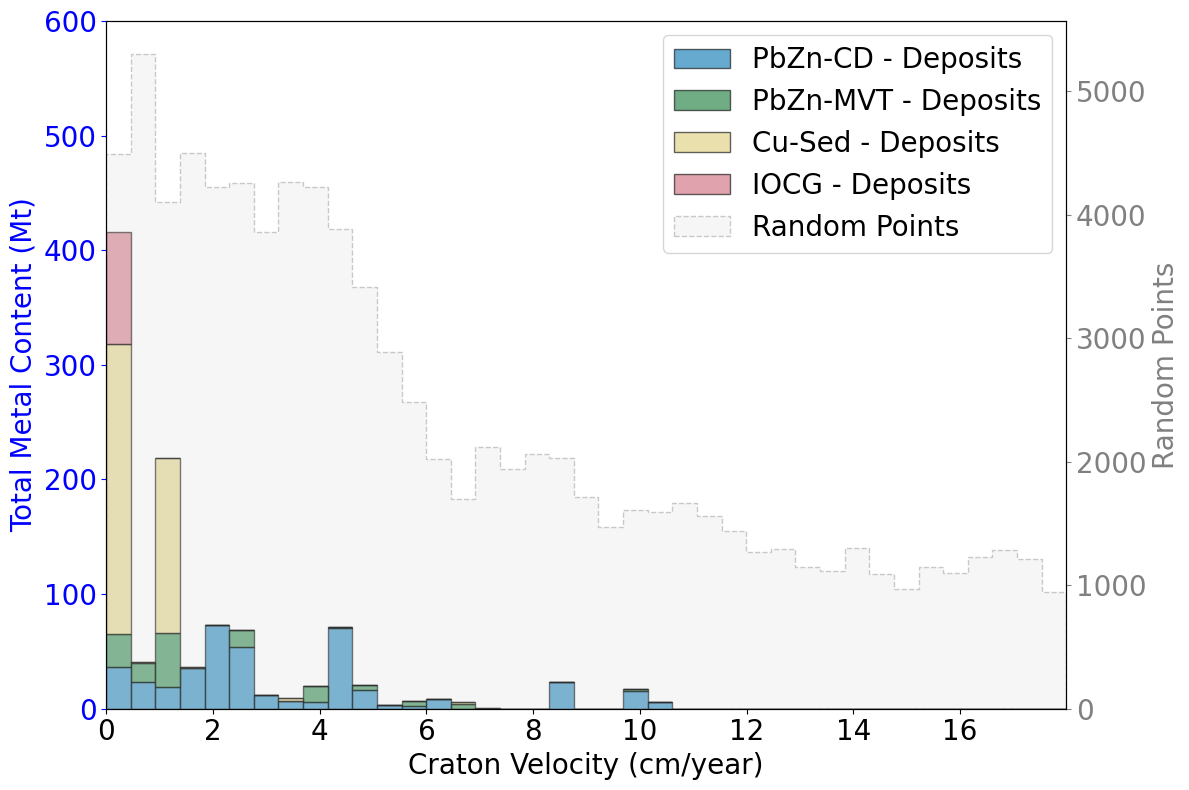

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your CSV file into a DataFrame
file_path = 'deposits_VS_random.csv'  # Update with your file path
df = pd.read_csv(file_path, low_memory=False)
df = df[(df['R_cr_ve'] >= 0) & (df['R_cr_ve'] <= 18)]

# Define colors based on deposit type
type_colors = {
    'PbZn-CD': '#0072B2',  # Blue
    'PbZn-MVT': '#117733',  # Green
    'Cu-Sed': '#DDCC77',  # Yellow
    'IOCG': '#CC6677'  # Pink
}

# Keep only `D_cr_ve` and `R_cr_ve`
deposit_column = 'D_cr_ve'
random_column = 'R_cr_ve'



# Function to plot stacked bar charts for deposits and separate random histograms
def plot_stacked_bar_chart_with_random(df, deposit_column, random_column, weights_column, type_colors):
    # Filter out types with no valid deposit data for the legend
    valid_types = df[~df[deposit_column].isna()]['Type'].unique()
    
    fig, ax1 = plt.subplots(figsize=(12, 8))
    ax2 = ax1.twinx()  # Create a second y-axis for the random data

    # Define consistent bin edges (using min/max of both data sets)
    min_val = 0  # Start from 0 for both deposit and random data
    max_val = max(df[deposit_column].max(), df[random_column].max())
    bin_edges = np.linspace(min_val, max_val, 40)  # 40 bins for consistency
    bin_width = bin_edges[1] - bin_edges[0]

    # Initialize an array to store the bottom position for stacking
    bottom = np.zeros(len(bin_edges) - 1)

    # Plot stacked bars for each deposit type
    for deposit_type in valid_types:
        type_data = df[df['Type'] == deposit_type]
        deposit_data = type_data[deposit_column].dropna()
        deposit_weights = type_data[weights_column]

        counts, _ = np.histogram(deposit_data, bins=bin_edges, weights=deposit_weights[:len(deposit_data)])
        ax1.bar(
            bin_edges[:-1] + (bin_width / 2),  # Shift bars to start from 0 properly
            counts,
            width=bin_width,
            color=type_colors.get(deposit_type, 'gray'),
            alpha=0.6,
            label=f'{deposit_type} - Deposits',
            edgecolor='black',
            bottom=bottom
        )
        # Update the bottom position for the next stack
        bottom += counts

    # Plot histogram for random data on the right y-axis
    random_data = df[random_column].dropna()  # Consider all rows in the random column
    random_weights = df[weights_column].dropna()

    ax2.hist(
        random_data,
        bins=bin_edges,  # Matching bin size to make comparison meaningful
        color='lightgray',
        alpha=0.2,
        label='Random Points',
        edgecolor='black',  # Thin border for each bar
        linestyle='dashed',
        histtype='stepfilled',
        density=False  # Absolute frequency
    )

    # Customize font sizes (doubling them) and colors
    font_size = 20  # Adjusted from default ~10

    ax1.set_xlabel('Craton Velocity (cm/year)', fontsize=font_size, color='black')  # X-axis in black
    ax1.set_ylabel('Total Metal Content (Mt)', fontsize=font_size, color='blue')  # Deposits in blue
    ax2.set_ylabel('Random Points', fontsize=font_size, color='gray')  # Random in gray

    ax1.tick_params(axis='x', labelsize=font_size, colors='black')  # X-axis in black
    ax1.tick_params(axis='y', labelsize=font_size, colors='blue')  # Deposits (left y-axis) in blue
    ax2.tick_params(axis='y', labelsize=font_size, colors='gray')  # Random (right y-axis) in gray

    ax1.set_ylim([0, 600])  # Adjust as needed
    ax1.set_xlim([0, max_val])  # Adjust to fit the data range

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=font_size)

    plt.tight_layout()
    plt.show()

# Plot for `D_cr_ve` and `R_cr_ve`
plot_stacked_bar_chart_with_random(
    df,
    deposit_column=deposit_column,
    random_column=random_column,
    weights_column='TM2',
    type_colors=type_colors
)


In [27]:
# Density Bars

In [28]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # Load your CSV file into a DataFrame
# file_path = 'deposits_VS_random.csv'  # Update with your file path
# df = pd.read_csv(file_path, low_memory=False)

# # Define colors based on deposit type
# type_colors = {
#     'PbZn-CD': '#0072B2',  # Blue
#     'PbZn-MVT': '#117733',  # Green
#     'Cu-Sed': '#DDCC77',  # Yellow
#     'IOCG': '#CC6677'      # Pink
# }

# # Keep only `D_cr_ve` and `R_cr_ve`
# deposit_column = 'D_cr_ve'
# random_column = 'R_cr_ve'

# # Function to plot stacked normalized bar charts for deposits and random histograms
# def plot_stacked_bar_chart_with_random(df, deposit_column, random_column, weights_column, type_colors):
#     # Filter out types with no valid deposit data
#     valid_types = df[~df[deposit_column].isna()]['Type'].unique()
    
#     fig, ax1 = plt.subplots(figsize=(12, 8))
#     ax2 = ax1.twinx()  # Create a second y-axis for the random data

#     # Define consistent bin edges (start from 0)
#     min_val = 0
#     max_val = max(df[deposit_column].max(), df[random_column].max())
#     bin_edges = np.linspace(min_val, max_val, 40)
#     bin_width = bin_edges[1] - bin_edges[0]

#     # Initialize an array to store the bottom position for stacking
#     bottom = np.zeros(len(bin_edges) - 1)

#     # Total metal content for normalization
#     total_metal = df[weights_column].sum()

#     # Plot stacked bars for each deposit type (normalized)
#     for deposit_type in valid_types:
#         type_data = df[df['Type'] == deposit_type]
#         deposit_data = type_data[deposit_column].dropna()
#         deposit_weights = type_data[weights_column]

#         counts, _ = np.histogram(deposit_data, bins=bin_edges, weights=deposit_weights[:len(deposit_data)])
#         if total_metal > 0:
#             counts = counts / total_metal  # Normalize the counts

#         ax1.bar(
#             bin_edges[:-1] + (bin_width / 2),
#             counts,
#             width=bin_width,
#             color=type_colors.get(deposit_type, 'gray'),
#             alpha=0.6,
#             label=f'{deposit_type} - Deposits',
#             edgecolor='black',
#             bottom=bottom
#         )
#         bottom += counts

#     # Plot histogram for random data on the right y-axis (normalized)
#     random_data = df[random_column].dropna()
#     random_weights = df[weights_column].dropna()

#     ax2.hist(
#         random_data,
#         bins=bin_edges,
#         color='lightgray',
#         alpha=0.2,
#         label='Random Points',
#         edgecolor='black',
#         linestyle='dashed',
#         histtype='stepfilled',
#         density=True
#     )

#     # Customize font sizes and labels
#     font_size = 20

#     ax1.set_xlabel('Craton Velocity (cm/year)', fontsize=font_size, color='black')
#     ax1.set_ylabel('Normalized Total Metal Content Density', fontsize=font_size, color='blue')
#     ax2.set_ylabel('Normalized Random Points Density', fontsize=font_size, color='gray')

#     ax1.tick_params(axis='x', labelsize=font_size, colors='black')
#     ax1.tick_params(axis='y', labelsize=font_size, colors='blue')
#     ax2.tick_params(axis='y', labelsize=font_size, colors='gray')

#     ax1.set_xlim([min_val, max_val])

#     # Combine and filter legends
#     lines1, labels1 = ax1.get_legend_handles_labels()
#     lines2, labels2 = ax2.get_legend_handles_labels()
#     ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=font_size)

#     plt.tight_layout()
#     plt.show()

# # Plot for `D_cr_ve` and `R_cr_ve`
# plot_stacked_bar_chart_with_random(
#     df,
#     deposit_column=deposit_column,
#     random_column=random_column,
#     weights_column='TM2',
#     type_colors=type_colors
# )


In [ ]:
# Density Graphs

In [29]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.neighbors import KernelDensity

# # Load data
# file_path = 'deposits_VS_random.csv'  # Update this to your actual path
# df = pd.read_csv(file_path, low_memory=False)

# # Set plot colors
# type_colors = {
#     'PbZn-CD': '#0072B2',
#     'PbZn-MVT': '#117733',
#     'Cu-Sed': '#DDCC77',
#     'IOCG': '#CC6677'
# }

# deposit_column = 'D_cr_ve'
# random_column = 'R_cr_ve'
# weights_column = 'TM2'

# def kde_smooth(data, weights, grid, bandwidth=1.0):
#     """Compute weighted KDE using sklearn"""
#     kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth)
#     kde.fit(data[:, None], sample_weight=weights)
#     log_density = kde.score_samples(grid[:, None])
#     return np.exp(log_density)

# def plot_kde_curves(df, deposit_column, random_column, weights_column, type_colors):
#     fig, ax = plt.subplots(figsize=(12, 8))

#     # Define KDE x-axis grid
#     min_val = 0
#     max_val = max(df[deposit_column].max(), df[random_column].max())
#     x_grid = np.linspace(min_val, max_val, 500)

#     # Plot deposit KDEs by type
#     valid_types = df[~df[deposit_column].isna()]['Type'].unique()
#     for deposit_type in valid_types:
#         type_data = df[df['Type'] == deposit_type]
#         deposit_data = type_data[deposit_column].dropna().values
#         deposit_weights = type_data.loc[type_data[deposit_column].notna(), weights_column].fillna(0).values

#         if len(deposit_data) > 1:
#             density = kde_smooth(deposit_data, deposit_weights / deposit_weights.sum(), x_grid, bandwidth=1.0)
#             ax.plot(x_grid, density, label=f'{deposit_type} - Deposits', color=type_colors.get(deposit_type, 'gray'), linewidth=2)

#     # Plot KDE for randoms
#     random_data = df[random_column].dropna().values
#     random_weights = df.loc[df[random_column].notna(), weights_column].fillna(0).values
#     if len(random_data) > 1:
#         random_density = kde_smooth(random_data, random_weights / random_weights.sum(), x_grid, bandwidth=1.0)
#         ax.plot(x_grid, random_density, label='Random Points', color='gray', linestyle='--', linewidth=3, alpha=0.5)

#     # Labels and formatting
#     font_size = 20
#     ax.set_xlabel('Craton Velocity (cm/year)', fontsize=font_size)
#     ax.set_ylabel('Probability Density', fontsize=font_size)
#     ax.tick_params(axis='x', labelsize=font_size)
#     ax.tick_params(axis='y', labelsize=font_size)
#     ax.set_xlim([0, max_val])
#     ax.legend(loc='upper right', fontsize=font_size)

#     plt.tight_layout()
#     plt.show()

# # Run it
# plot_kde_curves(
#     df,
#     deposit_column=deposit_column,
#     random_column=random_column,
#     weights_column=weights_column,
#     type_colors=type_colors
# )


# Kolmogorov-Smirnov Test

                                         Statistic       p-value
Kolmogorov-Smirnov Test               3.788089e-01  1.843159e-27
Mann-Whitney U Test                   4.492952e+06  5.381788e-39
Cohen's d (Weighted Deposits)        -1.195044e+00 -1.195044e+00
Jensen-Shannon Divergence (Weighted)  4.550736e-01  4.550736e-01
Chi-Square Test (Weighted)            1.442252e+02  5.474374e-14


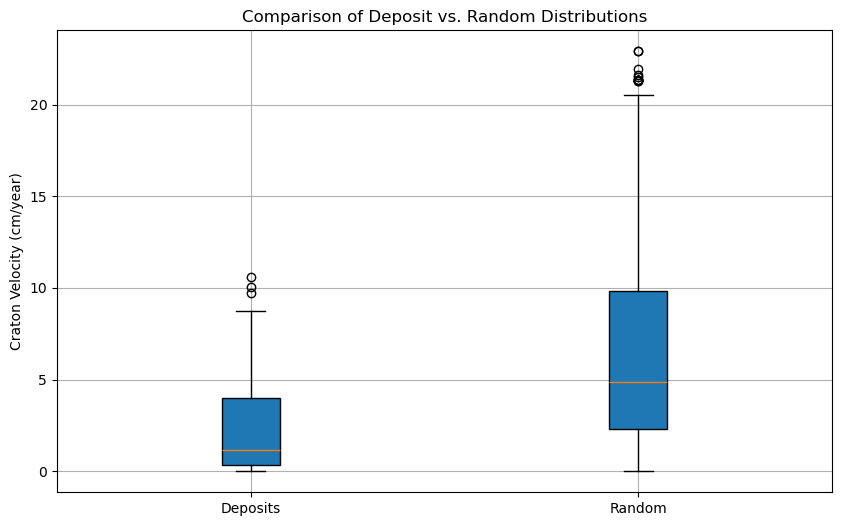

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp, mannwhitneyu, chi2_contingency
from scipy.spatial.distance import jensenshannon  # ✅ Correct JSD function
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv("deposits_VS_random.csv", low_memory=False)

# Define deposit and random columns
deposit_column = "D_cr_ve"
random_column = "R_cr_ve"
weights_column = "TM2"

# Drop NaN values for deposits and weights
valid_deposit_rows = df[deposit_column].notna() & df[weights_column].notna()
deposit_data = df.loc[valid_deposit_rows, deposit_column].values
deposit_weights = df.loc[valid_deposit_rows, weights_column].values

# Drop NaN values for random data (no weights applied)
random_data = df[random_column].dropna().values

# Kolmogorov-Smirnov Test (weights not applicable)
ks_stat, ks_pval = ks_2samp(deposit_data, random_data)

# Mann-Whitney U Test (weights not applicable)
mw_stat, mw_pval = mannwhitneyu(deposit_data, random_data, alternative='two-sided')

# ✅ Correct Cohen’s d Calculation
mean1 = np.average(deposit_data, weights=deposit_weights)
mean2 = np.mean(random_data)
var1 = np.average((deposit_data - mean1) ** 2, weights=deposit_weights)
std1 = np.sqrt(var1)
std2 = np.std(random_data, ddof=1)
pooled_std = np.sqrt((std1**2 + std2**2) / 2)
cohen_d = (mean1 - mean2) / pooled_std  # ✅ Only one value, no duplicate

# ✅ Correct Jensen-Shannon Divergence Calculation
hist_deposit, _ = np.histogram(deposit_data, bins=40, weights=deposit_weights, density=True)
hist_random, _ = np.histogram(random_data, bins=40, density=True)

# Normalize to probability distributions
hist_deposit += 1e-10  # Avoid division by zero
hist_random += 1e-10
hist_deposit /= np.sum(hist_deposit)
hist_random /= np.sum(hist_random)

js_divergence = jensenshannon(hist_deposit, hist_random)  # ✅ Correct function

# Chi-Square Test using Weighted Histogram
observed = np.vstack([hist_deposit, hist_random]) * len(deposit_data)
chi2_stat, chi2_pval, _, _ = chi2_contingency(observed)

# Print results
stats_results_weighted = {
    "Kolmogorov-Smirnov Test": {"Statistic": ks_stat, "p-value": ks_pval},
    "Mann-Whitney U Test": {"Statistic": mw_stat, "p-value": mw_pval},
    "Cohen's d (Weighted Deposits)": cohen_d,
    "Jensen-Shannon Divergence (Weighted)": js_divergence,
    "Chi-Square Test (Weighted)": {"Statistic": chi2_stat, "p-value": chi2_pval}
}

stats_df_weighted = pd.DataFrame(stats_results_weighted).T
print(stats_df_weighted)

# Visualization: Boxplots
plt.figure(figsize=(10, 6))
plt.boxplot([deposit_data, random_data], labels=["Deposits", "Random"], patch_artist=True)
plt.ylabel("Craton Velocity (cm/year)")
plt.title("Comparison of Deposit vs. Random Distributions")
plt.grid(True)
plt.show()


In [ ]:
# max Chi2

In [30]:
# import pandas as pd
# import numpy as np
# from scipy.stats import chi2_contingency

# # Load dataset
# df = pd.read_csv("deposits_VS_random.csv", low_memory=False)

# # Function to compute Chi-Square values
# def compute_chi_square_max(deposit_column, random_column, weights_column):
#     # Drop NaN values for deposits and weights
#     valid_deposit_rows = df[deposit_column].notna() & df[weights_column].notna()
#     deposit_data = df.loc[valid_deposit_rows, deposit_column].values
#     deposit_weights = df.loc[valid_deposit_rows, weights_column].values

#     # Drop NaN values for random data
#     random_data = df[random_column].dropna().values

#     # Weighted histogram
#     hist_deposit, _ = np.histogram(deposit_data, bins=40, weights=deposit_weights, density=True)
#     hist_random, _ = np.histogram(random_data, bins=40, density=True)

#     # Normalize to probability distributions
#     hist_deposit += 1e-10
#     hist_random += 1e-10
#     hist_deposit /= np.sum(hist_deposit)
#     hist_random /= np.sum(hist_random)

#     total_deposit = len(deposit_data)

#     # Observed Chi-Square
#     observed = np.vstack([hist_deposit, hist_random]) * total_deposit
#     chi2_stat, chi2_pval, _, _ = chi2_contingency(observed)

#     # Maximum Chi-Square (perfect separation)
#     bins = len(hist_deposit)
#     half = bins // 2
#     perfect_deposit = np.array([1.0] * half + [0.0] * (bins - half))
#     perfect_random = np.array([0.0] * half + [1.0] * (bins - half))

#     perfect_deposit = perfect_deposit / np.sum(perfect_deposit) * total_deposit
#     perfect_random = perfect_random / np.sum(perfect_random) * total_deposit
#     perfect_observed = np.vstack([perfect_deposit, perfect_random])
#     chi2_max, _, _, _ = chi2_contingency(perfect_observed)

#     relative_percent = (chi2_stat / chi2_max) * 100

#     return chi2_stat, chi2_max, relative_percent

# # Compute for each variable
# results = {
#     "Craton Velocity": compute_chi_square_max("D_cr_ve", "R_cr_ve", "TM2"),
#     "Subduction Velocity": compute_chi_square_max("D_sb_ve", "R_sb_ve", "TM2"),
#     "Distance to Trench": compute_chi_square_max("D_ds_tr", "R_ds_tr", "TM2"),
# }

# # Convert to DataFrame
# chi_square_df = pd.DataFrame(results, index=["Observed Chi2", "Max Chi2", "Relative %"]).T

# # Display results
# print(chi_square_df)


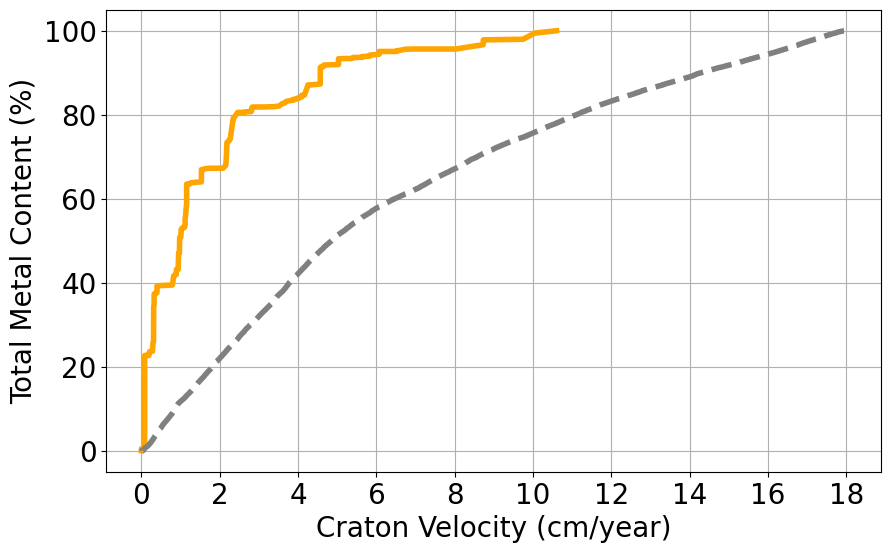

In [31]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp, mannwhitneyu, chi2_contingency
from sklearn.metrics import mutual_info_score
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv("deposits_VS_random.csv", low_memory=False)
df = df[(df['R_cr_ve'] >= 0) & (df['R_cr_ve'] <= 18)]


# Define deposit and random columns
deposit_column = "D_cr_ve"
random_column = "R_cr_ve"
weights_column = "TM2"

# Drop NaN values for deposits and weights
valid_deposit_rows = df[deposit_column].notna() & df[weights_column].notna()
deposit_data = df.loc[valid_deposit_rows, deposit_column].values
deposit_weights = df.loc[valid_deposit_rows, weights_column].values

# Drop NaN values for random data (no weights applied)
random_data = df[random_column].dropna().values

# Sort data for CDF
sorted_deposit = np.sort(deposit_data)
sorted_random = np.sort(random_data)

# Compute the cumulative distribution function (CDF) with weights
cdf_deposit = np.cumsum(deposit_weights[np.argsort(deposit_data)]) / np.sum(deposit_weights)
cdf_random = np.arange(1, len(sorted_random) + 1) / len(sorted_random)  # No weights for random data

# Plot the cumulative distribution functions (CDF)
plt.figure(figsize=(10, 6))
plt.plot(sorted_deposit, cdf_deposit, label="All Deposits", color="orange", linewidth=4)
plt.plot(sorted_random, cdf_random, label="Random Points", color="grey", linestyle="dashed", linewidth=4)

# Labels and legend with increased font size
plt.xlabel("Craton Velocity (cm/year)", fontsize=20)
plt.ylabel("Total Metal Content (%)", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(np.linspace(0, 1, 6), labels=[f"{int(y*100)}" for y in np.linspace(0, 1, 6)], fontsize=20)  # Multiply y-axis labels by 100
#plt.legend(fontsize=20)
plt.grid(True)

# Set x-axis interval to every 2 units and ensure it extends to the max of random data
plt.xticks(np.arange(min(sorted_deposit), max(sorted_random) + 2, 2))

# Show the plot
plt.show()


# Convergence Rate (subductin velocity)

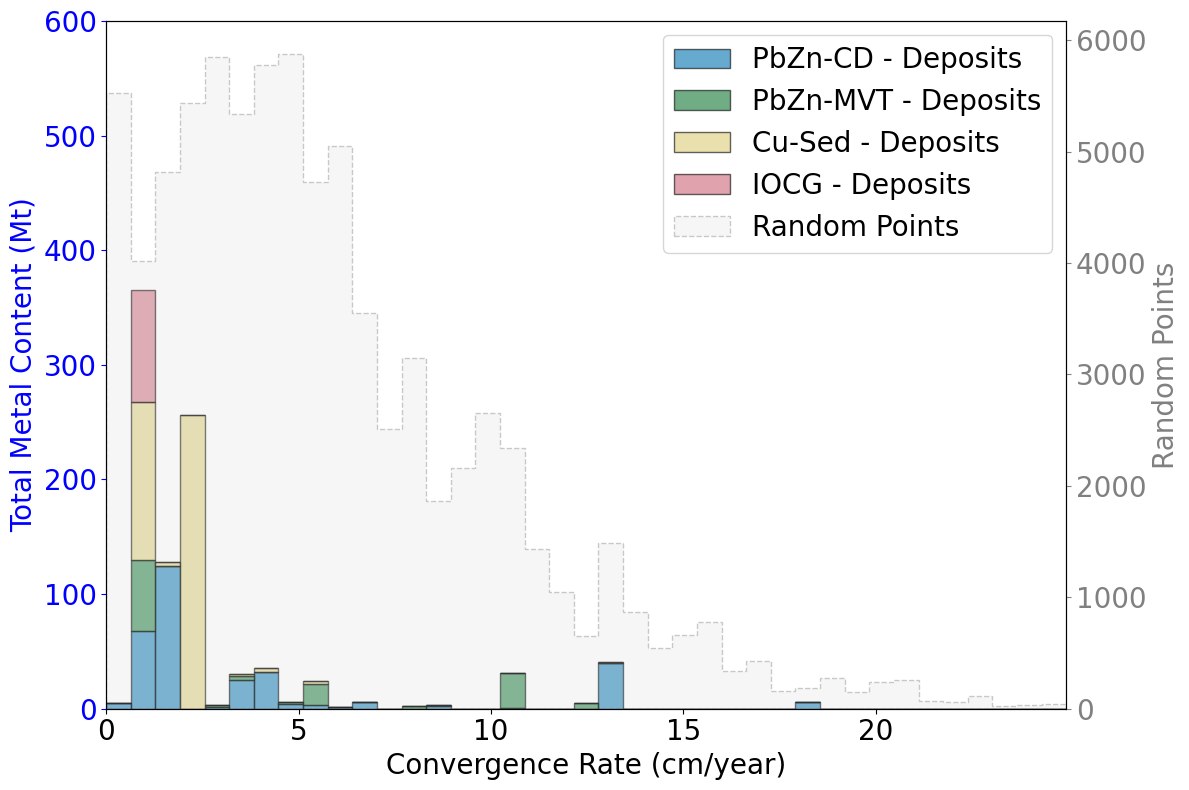

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your CSV file into a DataFrame
file_path = 'deposits_VS_random.csv'  # Update with your file path
df = pd.read_csv(file_path, low_memory=False)
df = df[(df['R_sb_ve'] >= 0) & (df['R_sb_ve'] <= 25)]

# Define colors based on deposit type
type_colors = {
    'PbZn-CD': '#0072B2',  # Blue
    'PbZn-MVT': '#117733',  # Green
    'Cu-Sed': '#DDCC77',  # Yellow
    'IOCG': '#CC6677'  # Pink
}

# Replace NaN values in 'Type' with 'Unknown'
df['Type'] = df['Type'].fillna('Unknown')

# Keep only `D_sb_ve` and `R_sb_ve`
deposit_column = 'D_sb_ve'
random_column = 'R_sb_ve'

# Function to plot stacked bar charts for deposits and separate random histograms
def plot_stacked_bar_chart_with_random(df, deposit_column, random_column, weights_column, type_colors):
    unique_types = df['Type'].unique()
    fig, ax1 = plt.subplots(figsize=(12, 8))
    ax2 = ax1.twinx()  # Create a second y-axis for the random data

    # Define consistent bin edges (using min/max of both data sets)
    min_val = 0  # Start from 0 for both deposit and random data
    max_val = max(df[deposit_column].max(), df[random_column].max())
    bin_edges = np.linspace(min_val, max_val, 40)  # 40 bins for consistency
    bin_width = bin_edges[1] - bin_edges[0]

    # Initialize an array to store the bottom position for stacking
    bottom = np.zeros(len(bin_edges) - 1)

    # Plot stacked bars for each deposit type
    for deposit_type in unique_types:
        if deposit_type == 'Unknown':
            continue  # Skip the 'Unknown' type
        type_data = df[df['Type'] == deposit_type]
        deposit_data = type_data[deposit_column].dropna()
        deposit_weights = type_data[weights_column]

        counts, _ = np.histogram(deposit_data, bins=bin_edges, weights=deposit_weights[:len(deposit_data)])
        ax1.bar(
            bin_edges[:-1] + (bin_width / 2),  # Shift bars to start from 0 properly
            counts,
            width=bin_width,
            color=type_colors.get(deposit_type, 'gray'),
            alpha=0.6,
            label=f'{deposit_type} - Deposits',
            edgecolor='black',
            bottom=bottom
        )
        # Update the bottom position for the next stack
        bottom += counts

    # Plot histogram for random data on the right y-axis
    random_data = df[random_column].dropna()  # Consider all rows in the random column
    random_weights = df[weights_column].dropna()

    ax2.hist(
        random_data,
        bins=bin_edges,  # Matching bin size to make comparison meaningful
        color='lightgray',
        alpha=0.2,
        label='Random Points',
        edgecolor='black',  # Thin border for each bar
        linestyle='dashed',
        histtype='stepfilled',
        density=False  # Absolute frequency
    )

    # Customize font sizes (doubling them) and colors
    font_size = 20  # Adjusted from default ~10

    ax1.set_xlabel('Convergence Rate (cm/year)', fontsize=font_size, color='black')  # X-axis in black
    ax1.set_ylabel('Total Metal Content (Mt)', fontsize=font_size, color='blue')  # Deposits in blue
    ax2.set_ylabel('Random Points', fontsize=font_size, color='gray')  # Random in gray

    ax1.tick_params(axis='x', labelsize=font_size, colors='black')  # X-axis in black
    ax1.tick_params(axis='y', labelsize=font_size, colors='blue')  # Deposits (left y-axis) in blue
    ax2.tick_params(axis='y', labelsize=font_size, colors='gray')  # Random (right y-axis) in gray

    ax1.set_ylim([0, 600])  # Adjust as needed
    ax1.set_xlim([0, max_val])  # Adjust to fit the data range

    # Combine legends from both axes, excluding 'Unknown'
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    filtered_legend = [(line, label) for line, label in zip(lines1 + lines2, labels1 + labels2) if 'Unknown' not in label]
    filtered_lines, filtered_labels = zip(*filtered_legend) if filtered_legend else ([], [])
    ax1.legend(filtered_lines, filtered_labels, loc='upper right', fontsize=font_size)

    plt.tight_layout()
    plt.show()

# Plot for `D_sb_ve` and `R_sb_ve`
plot_stacked_bar_chart_with_random(
    df,
    deposit_column=deposit_column,
    random_column=random_column,
    weights_column='TM2',
    type_colors=type_colors
)


In [ ]:
# Density Bar

In [36]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # Load your CSV file into a DataFrame
# file_path = 'deposits_VS_random.csv'  # Update with your file path
# df = pd.read_csv(file_path, low_memory=False)

# # Define colors based on deposit type
# type_colors = {
#     'PbZn-CD': '#0072B2',  # Blue
#     'PbZn-MVT': '#117733',  # Green
#     'Cu-Sed': '#DDCC77',  # Yellow
#     'IOCG': '#CC6677'      # Pink
# }

# # Replace NaN values in 'Type' with 'Unknown'
# df['Type'] = df['Type'].fillna('Unknown')

# # Keep only `D_sb_ve` and `R_sb_ve`
# deposit_column = 'D_sb_ve'
# random_column = 'R_sb_ve'

# # Function to plot stacked normalized bar charts for deposits and random histograms
# def plot_stacked_bar_chart_with_random(df, deposit_column, random_column, weights_column, type_colors):
#     unique_types = df['Type'].unique()
#     fig, ax1 = plt.subplots(figsize=(12, 8))
#     ax2 = ax1.twinx()  # Create a second y-axis for the random data

#     # Define consistent bin edges (start from 0)
#     min_val = 0
#     max_val = max(df[deposit_column].max(), df[random_column].max())
#     bin_edges = np.linspace(min_val, max_val, 40)
#     bin_width = bin_edges[1] - bin_edges[0]

#     # Initialize an array to store the bottom position for stacking
#     bottom = np.zeros(len(bin_edges) - 1)

#     # Total metal content for normalization
#     total_metal = df[weights_column].sum()

#     # Plot stacked bars for each deposit type (normalized)
#     for deposit_type in unique_types:
#         if deposit_type == 'Unknown':
#             continue
#         type_data = df[df['Type'] == deposit_type]
#         deposit_data = type_data[deposit_column].dropna()
#         deposit_weights = type_data[weights_column]

#         counts, _ = np.histogram(deposit_data, bins=bin_edges, weights=deposit_weights[:len(deposit_data)])
#         if total_metal > 0:
#             counts = counts / total_metal  # Normalize the counts

#         ax1.bar(
#             bin_edges[:-1] + (bin_width / 2),
#             counts,
#             width=bin_width,
#             color=type_colors.get(deposit_type, 'gray'),
#             alpha=0.6,
#             label=f'{deposit_type} - Deposits',
#             edgecolor='black',
#             bottom=bottom
#         )
#         bottom += counts

#     # Plot histogram for random data on the right y-axis (normalized)
#     random_data = df[random_column].dropna()
#     random_weights = df[weights_column].dropna()

#     ax2.hist(
#         random_data,
#         bins=bin_edges,
#         color='lightgray',
#         alpha=0.2,
#         label='Random Points',
#         edgecolor='black',
#         linestyle='dashed',
#         histtype='stepfilled',
#         density=True
#     )

#     # Customize font sizes and labels
#     font_size = 20

#     ax1.set_xlabel('Convergence Rate (cm/year)', fontsize=font_size, color='black')
#     ax1.set_ylabel('Normalized Total Metal Content Density', fontsize=font_size, color='blue')
#     ax2.set_ylabel('Normalized Random Points Density', fontsize=font_size, color='gray')

#     ax1.tick_params(axis='x', labelsize=font_size, colors='black')
#     ax1.tick_params(axis='y', labelsize=font_size, colors='blue')
#     ax2.tick_params(axis='y', labelsize=font_size, colors='gray')

#     ax1.set_xlim([min_val, max_val])

#     # Combine and filter legends
#     lines1, labels1 = ax1.get_legend_handles_labels()
#     lines2, labels2 = ax2.get_legend_handles_labels()
#     filtered_legend = [(line, label) for line, label in zip(lines1 + lines2, labels1 + labels2) if 'Unknown' not in label]
#     filtered_lines, filtered_labels = zip(*filtered_legend) if filtered_legend else ([], [])
#     ax1.legend(filtered_lines, filtered_labels, loc='upper right', fontsize=font_size)

#     plt.tight_layout()
#     plt.show()

# # Plot for `D_sb_ve` and `R_sb_ve`
# plot_stacked_bar_chart_with_random(
#     df,
#     deposit_column=deposit_column,
#     random_column=random_column,
#     weights_column='TM2',
#     type_colors=type_colors
# )


In [ ]:
# Density Graph

In [37]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.neighbors import KernelDensity

# # Load data
# file_path = 'deposits_VS_random.csv'  # Update this to your actual path
# df = pd.read_csv(file_path, low_memory=False)

# # Set plot colors
# type_colors = {
#     'PbZn-CD': '#0072B2',
#     'PbZn-MVT': '#117733',
#     'Cu-Sed': '#DDCC77',
#     'IOCG': '#CC6677'
# }

# deposit_column = 'D_sb_ve'
# random_column = 'R_sb_ve'
# weights_column = 'TM2'

# def kde_smooth(data, weights, grid, bandwidth=1.0):
#     """Compute weighted KDE using sklearn"""
#     kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth)
#     kde.fit(data[:, None], sample_weight=weights)
#     log_density = kde.score_samples(grid[:, None])
#     return np.exp(log_density)

# def plot_kde_curves(df, deposit_column, random_column, weights_column, type_colors):
#     fig, ax = plt.subplots(figsize=(12, 8))

#     # Define KDE x-axis grid
#     min_val = 0
#     max_val = max(df[deposit_column].max(), df[random_column].max())
#     x_grid = np.linspace(min_val, max_val, 500)

#     # Plot deposit KDEs by type
#     valid_types = df[~df[deposit_column].isna()]['Type'].unique()
#     for deposit_type in valid_types:
#         type_data = df[df['Type'] == deposit_type]
#         deposit_data = type_data[deposit_column].dropna().values
#         deposit_weights = type_data.loc[type_data[deposit_column].notna(), weights_column].fillna(0).values

#         if len(deposit_data) > 1:
#             density = kde_smooth(deposit_data, deposit_weights / deposit_weights.sum(), x_grid, bandwidth=1.0)
#             ax.plot(x_grid, density, label=f'{deposit_type} - Deposits', color=type_colors.get(deposit_type, 'gray'), linewidth=2)

#     # Plot KDE for randoms
#     random_data = df[random_column].dropna().values
#     random_weights = df.loc[df[random_column].notna(), weights_column].fillna(0).values
#     if len(random_data) > 1:
#         random_density = kde_smooth(random_data, random_weights / random_weights.sum(), x_grid, bandwidth=1.0)
#         ax.plot(x_grid, random_density, label='Random Points', color='gray', linestyle='--', linewidth=3, alpha=0.5)

#     # Labels and formatting
#     font_size = 20
#     ax.set_xlabel('Convergence Rate (cm/year)', fontsize=font_size)
#     ax.set_ylabel('Probability Density', fontsize=font_size)
#     ax.tick_params(axis='x', labelsize=font_size)
#     ax.tick_params(axis='y', labelsize=font_size)
#     ax.set_xlim([0, max_val])
#     ax.legend(loc='upper right', fontsize=font_size)

#     plt.tight_layout()
#     plt.show()

# # Run it
# plot_kde_curves(
#     df,
#     deposit_column=deposit_column,
#     random_column=random_column,
#     weights_column=weights_column,
#     type_colors=type_colors
# )


In [ ]:
# Kolmogorov-Smirnov Test

                                         Statistic       p-value
Kolmogorov-Smirnov Test               3.430789e-01  1.811373e-22
Mann-Whitney U Test                   6.956179e+06  7.397555e-11
Cohen's d (Weighted Deposits)        -4.514302e-01 -4.514302e-01
Jensen-Shannon Divergence (Weighted)  7.732706e-01  7.732706e-01
Chi-Square Test (Weighted)            3.717689e+02  7.157852e-56


C:\Users\hshi9735\AppData\Local\Temp\ipykernel_20160\1933209731.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([deposit_data, random_data], labels=["Deposits", "Random"], patch_artist=True)


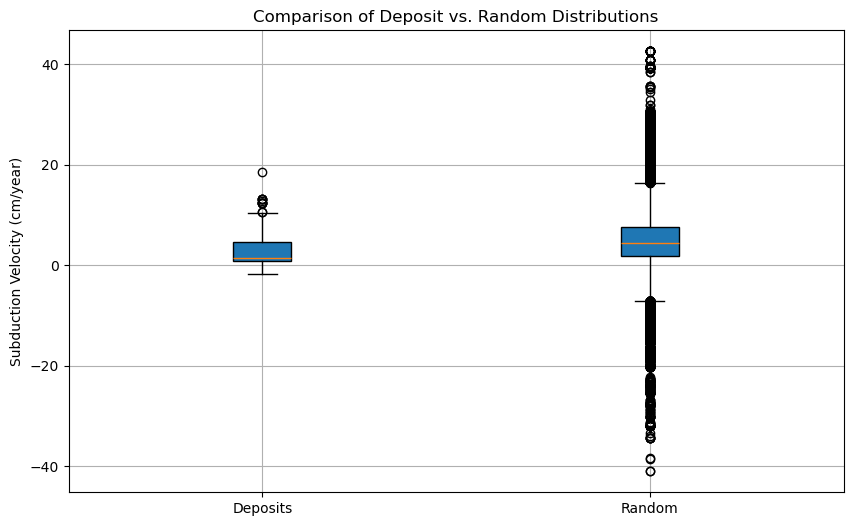

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp, mannwhitneyu, chi2_contingency
from scipy.spatial.distance import jensenshannon  # ✅ Correct JSD function
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv("deposits_VS_random.csv", low_memory=False)

# Define deposit and random columns
deposit_column = "D_sb_ve"
random_column = "R_sb_ve"
weights_column = "TM2"

# Drop NaN values for deposits and weights
valid_deposit_rows = df[deposit_column].notna() & df[weights_column].notna()
deposit_data = df.loc[valid_deposit_rows, deposit_column].values
deposit_weights = df.loc[valid_deposit_rows, weights_column].values

# Drop NaN values for random data (no weights applied)
random_data = df[random_column].dropna().values

# ✅ Kolmogorov-Smirnov Test (weights not applicable)
ks_stat, ks_pval = ks_2samp(deposit_data, random_data)

# ✅ Mann-Whitney U Test (weights not applicable)
mw_stat, mw_pval = mannwhitneyu(deposit_data, random_data, alternative="two-sided")

# ✅ Corrected Cohen’s d Calculation (Using Weighted Mean & Standard Deviation)
mean1 = np.average(deposit_data, weights=deposit_weights)
mean2 = np.mean(random_data)
var1 = np.average((deposit_data - mean1) ** 2, weights=deposit_weights)
std1 = np.sqrt(var1)
std2 = np.std(random_data, ddof=1)
pooled_std = np.sqrt((std1**2 + std2**2) / 2)
cohen_d = (mean1 - mean2) / pooled_std  # ✅ Corrected Calculation

# ✅ Corrected Jensen-Shannon Divergence Calculation
hist_deposit, _ = np.histogram(deposit_data, bins=40, weights=deposit_weights, density=True)
hist_random, _ = np.histogram(random_data, bins=40, density=True)

# Normalize to probability distributions
hist_deposit += 1e-10  # Avoid division by zero
hist_random += 1e-10
hist_deposit /= np.sum(hist_deposit)
hist_random /= np.sum(hist_random)

js_divergence = jensenshannon(hist_deposit, hist_random)  # ✅ Correct function

# ✅ Chi-Square Test using Weighted Histogram
observed = np.vstack([hist_deposit, hist_random]) * len(deposit_data)
chi2_stat, chi2_pval, _, _ = chi2_contingency(observed)

# ✅ Print results in a clean format
stats_results_weighted = {
    "Kolmogorov-Smirnov Test": {"Statistic": ks_stat, "p-value": ks_pval},
    "Mann-Whitney U Test": {"Statistic": mw_stat, "p-value": mw_pval},
    "Cohen's d (Weighted Deposits)": cohen_d,
    "Jensen-Shannon Divergence (Weighted)": js_divergence,
    "Chi-Square Test (Weighted)": {"Statistic": chi2_stat, "p-value": chi2_pval}
}

stats_df_weighted = pd.DataFrame(stats_results_weighted).T
print(stats_df_weighted)

# ✅ Visualization: Boxplots
plt.figure(figsize=(10, 6))
plt.boxplot([deposit_data, random_data], labels=["Deposits", "Random"], patch_artist=True)
plt.ylabel("Convergence Rate (cm/year)")
plt.title("Comparison of Deposit vs. Random Distributions")
plt.grid(True)
plt.show()


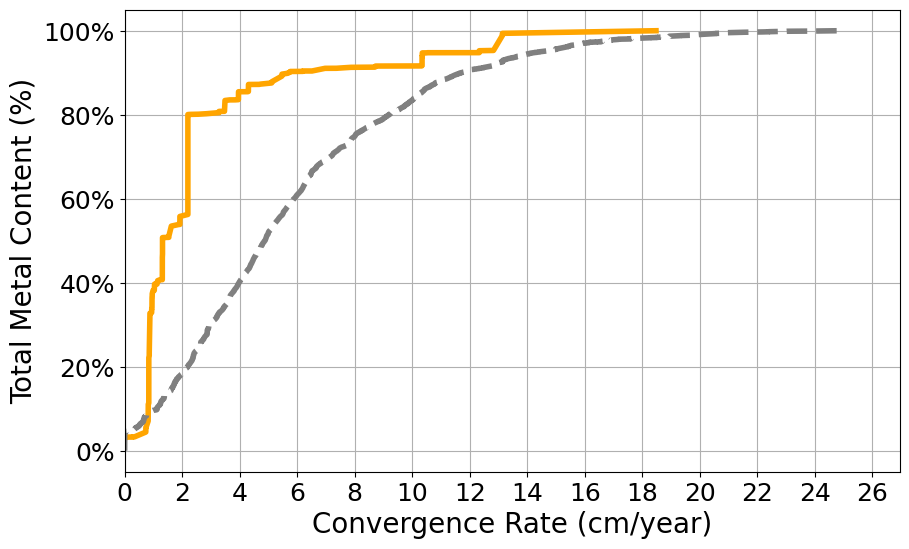

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv("deposits_VS_random.csv", low_memory=False)
df = df[(df['R_sb_ve'] >= 0) & (df['R_sb_ve'] <= 25)]

# Define deposit and random columns
deposit_column = 'D_sb_ve'
random_column = 'R_sb_ve'
weights_column = "TM2"

# Drop NaN values for deposits and weights
valid_deposit_rows = df[deposit_column].notna() & df[weights_column].notna()
deposit_data = df.loc[valid_deposit_rows, deposit_column].values
deposit_weights = df.loc[valid_deposit_rows, weights_column].values

# Drop NaN values for random data (no weights applied)
random_data = df[random_column].dropna().values

# Ensure valid data exists before sorting
if len(deposit_data) > 0 and len(random_data) > 0:
    sorted_deposit = np.sort(deposit_data)
    sorted_random = np.sort(random_data)

    # Compute the cumulative distribution function (CDF) with weights
    cdf_deposit = np.cumsum(deposit_weights[np.argsort(deposit_data)]) / np.sum(deposit_weights)
    cdf_random = np.arange(1, len(sorted_random) + 1) / len(sorted_random)  # No weights for random data

    # Plot the cumulative distribution functions (CDF)
    plt.figure(figsize=(10, 6))
    plt.plot(sorted_deposit, cdf_deposit, label="All Deposits", color="orange", linewidth=4)
    plt.plot(sorted_random, cdf_random, label="Random Points", color="grey", linestyle="dashed", linewidth=4)

    # Labels and legend with increased font size
    plt.xlabel("Convergence Rate (cm/year)", fontsize=20)
    plt.ylabel("Total Metal Content (%)", fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)

    # Adjust the y-axis to show percentage values correctly
    plt.yticks(np.linspace(0, 1, 6), labels=[f"{int(y*100)}%" for y in np.linspace(0, 1, 6)])

    # Ensure the x-axis starts at 0 and extends to the max random data value
    plt.xlim(0, max(max(sorted_deposit), max(sorted_random)) + 2)
    plt.xticks(np.arange(0, max(max(sorted_deposit), max(sorted_random)) + 2, 2))

    #plt.legend(fontsize=18)
    plt.grid(True)

    # Show the updated plot
    plt.show()
else:
    print("Insufficient valid data for plotting.")

# distance to subduction trench

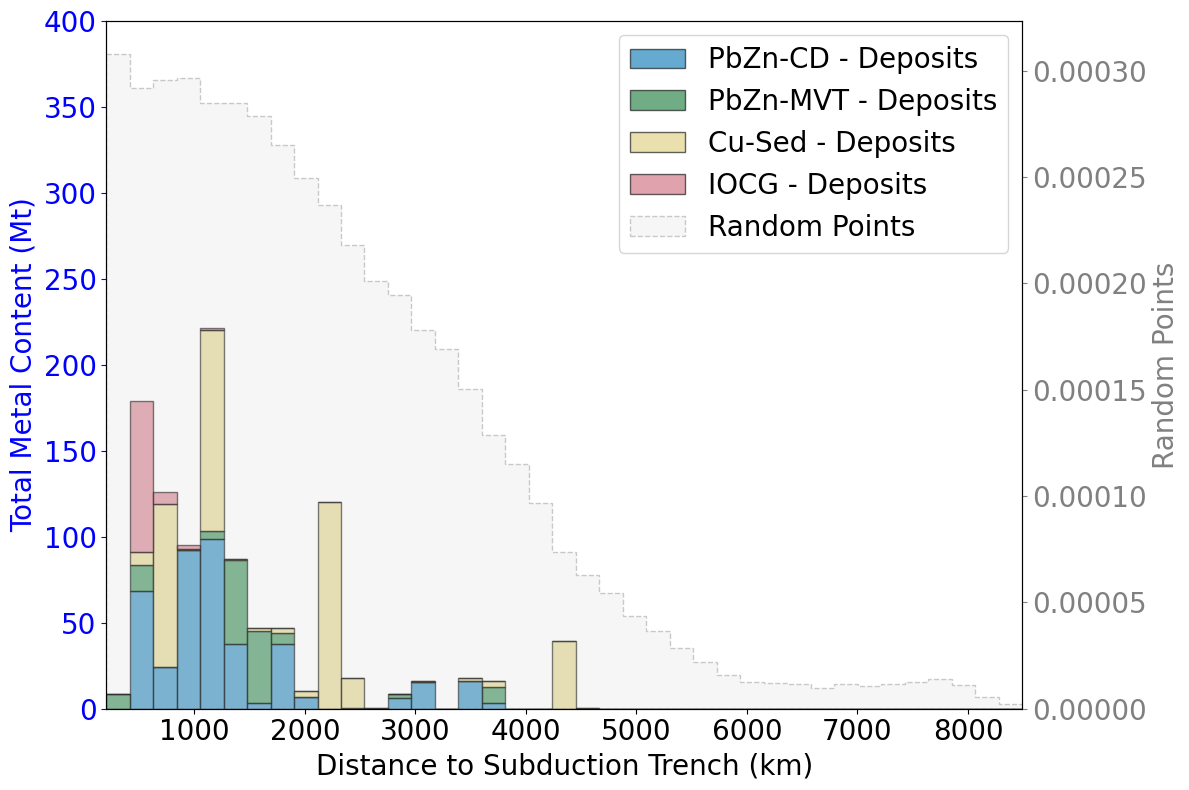

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your CSV file into a DataFrame
file_path = 'deposits_VS_random.csv'  # Update with your file path
df = pd.read_csv(file_path, low_memory=False)
df = df[(df['R_ds_tr'] >= 0) & (df['R_ds_tr'] <= 8500)]

# Define updated colors based on deposit type
type_colors = {
    'PbZn-CD': '#0072B2',  # Blue
    'PbZn-MVT': '#117733',  # Green
    'Cu-Sed': '#DDCC77',  # Yellow
    'IOCG': '#CC6677'  # Pink
}

# Replace NaN values in 'Type' with 'Unknown'
df['Type'] = df['Type'].fillna('Unknown')

# Function to plot stacked bar charts for deposits and separate random histograms
def plot_stacked_bar_chart_with_random(df, deposit_column, random_column, weights_column, type_colors):
    unique_types = df['Type'].unique()
    fig, ax1 = plt.subplots(figsize=(12, 8))
    ax2 = ax1.twinx()  # Create a second y-axis for the random data

    # Define consistent bin edges (using min/max of both data sets)
    min_val = df[deposit_column].min()  # Use minimum value of deposit data
    max_val = max(df[deposit_column].max(), df[random_column].max())
    bin_edges = np.linspace(min_val, max_val, 40)  # 40 bins for consistency
    bin_width = bin_edges[1] - bin_edges[0]

    # Initialize an array to store the bottom position for stacking
    bottom = np.zeros(len(bin_edges) - 1)

    # Plot stacked bars for each deposit type
    for deposit_type in unique_types:
        if deposit_type == 'Unknown':  # Skip the 'Unknown' type
            continue
        type_data = df[df['Type'] == deposit_type]
        deposit_data = type_data[deposit_column].dropna()
        deposit_weights = type_data[weights_column]

        if len(deposit_data) > 0:  # Only plot if there is data for this type
            counts, _ = np.histogram(deposit_data, bins=bin_edges, weights=deposit_weights[:len(deposit_data)])
            ax1.bar(
                bin_edges[:-1] + (bin_width / 2),  # Shift bars to start from 0 properly
                counts,
                width=bin_width,
                color=type_colors.get(deposit_type, 'gray'),
                alpha=0.6,
                label=f'{deposit_type} - Deposits',
                edgecolor='black',
                bottom=bottom
            )
            # Update the bottom position for the next stack
            bottom += counts

    # Plot histogram for random data on the right y-axis
    random_data = df[random_column].dropna()  # Consider all rows in the random column
    random_weights = df[weights_column].dropna()

    ax2.hist(
        random_data,
        bins=bin_edges,  # Matching bin size to make comparison meaningful
        color='lightgray',
        alpha=0.2,
        label='Random Points',
        edgecolor='black',  # Thin border for each bar
        linestyle='dashed',
        histtype='stepfilled',
        density=True  # Absolute frequency
    )

    # Customize font sizes (doubling them) and colors
    font_size = 20  # Adjusted from default ~10

    ax1.set_xlabel('Distance to Subduction Trench (km)', fontsize=font_size, color='black')  # X-axis in black
    ax1.set_ylabel('Total Metal Content (Mt)', fontsize=font_size, color='blue')  # Deposits in blue
    ax2.set_ylabel('Random Points', fontsize=font_size, color='gray')  # Random in gray

    ax1.tick_params(axis='x', labelsize=font_size, colors='black')  # X-axis in black
    ax1.tick_params(axis='y', labelsize=font_size, colors='blue')  # Deposits (left y-axis) in blue
    ax2.tick_params(axis='y', labelsize=font_size, colors='gray')  # Random (right y-axis) in gray

    ax1.set_ylim([0, 400])  # Adjust dynamically as needed
    ax1.set_xlim([min_val, max_val])  # Adjust to cover full range of data

    # Combine legends from both axes, excluding 'Unknown'
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    filtered_legend = [(line, label) for line, label in zip(lines1 + lines2, labels1 + labels2) if 'Unknown' not in label]
    filtered_lines, filtered_labels = zip(*filtered_legend) if filtered_legend else ([], [])
    ax1.legend(filtered_lines, filtered_labels, loc='upper right', fontsize=font_size)

    plt.tight_layout()
    plt.show()

# Plotting for "D_ds_tr" vs "R_ds_tr"
plot_stacked_bar_chart_with_random(
    df,
    deposit_column='D_ds_tr',
    random_column='R_ds_tr',
    weights_column='TM2',
    type_colors=type_colors
)


In [41]:
# Density Bar

In [42]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # Load your CSV file into a DataFrame
# file_path = 'deposits_VS_random.csv'  # Update with your file path
# df = pd.read_csv(file_path, low_memory=False)

# # Define updated colors based on deposit type
# type_colors = {
#     'PbZn-CD': '#0072B2',  # Blue
#     'PbZn-MVT': '#117733',  # Green
#     'Cu-Sed': '#DDCC77',  # Yellow
#     'IOCG': '#CC6677'  # Pink
# }

# # Replace NaN values in 'Type' with 'Unknown'
# df['Type'] = df['Type'].fillna('Unknown')

# # Function to plot stacked normalized bar charts for deposits and random histograms
# def plot_stacked_bar_chart_with_random(df, deposit_column, random_column, weights_column, type_colors):
#     unique_types = df['Type'].unique()
#     fig, ax1 = plt.subplots(figsize=(12, 8))
#     ax2 = ax1.twinx()  # Create a second y-axis for the random data

#     # Define consistent bin edges (using min/max of both data sets)
#     min_val = df[deposit_column].min()
#     max_val = max(df[deposit_column].max(), df[random_column].max())
#     bin_edges = np.linspace(min_val, max_val, 40)
#     bin_width = bin_edges[1] - bin_edges[0]

#     # Initialize an array to store the bottom position for stacking
#     bottom = np.zeros(len(bin_edges) - 1)

#     # Calculate total metal content for normalization
#     total_metal = df[weights_column].sum()

#     # Plot stacked bars for each deposit type (normalized)
#     for deposit_type in unique_types:
#         if deposit_type == 'Unknown':
#             continue
#         type_data = df[df['Type'] == deposit_type]
#         deposit_data = type_data[deposit_column].dropna()
#         deposit_weights = type_data[weights_column]

#         if len(deposit_data) > 0:
#             counts, _ = np.histogram(deposit_data, bins=bin_edges, weights=deposit_weights[:len(deposit_data)])
#             if total_metal > 0:
#                 counts = counts / total_metal  # Normalize the counts

#             ax1.bar(
#                 bin_edges[:-1] + (bin_width / 2),
#                 counts,
#                 width=bin_width,
#                 color=type_colors.get(deposit_type, 'gray'),
#                 alpha=0.6,
#                 label=f'{deposit_type} - Deposits',
#                 edgecolor='black',
#                 bottom=bottom
#             )
#             bottom += counts

#     # Plot histogram for random data on the right y-axis (already normalized with density=True)
#     random_data = df[random_column].dropna()
#     random_weights = df[weights_column].dropna()

#     ax2.hist(
#         random_data,
#         bins=bin_edges,
#         color='lightgray',
#         alpha=0.2,
#         label='Random Points',
#         edgecolor='black',
#         linestyle='dashed',
#         histtype='stepfilled',
#         density=True
#     )

#     # Customize font sizes and labels
#     font_size = 20

#     ax1.set_xlabel('Distance to Subduction Trench (km)', fontsize=font_size, color='black')
#     ax1.set_ylabel('Normalized Total Metal Content Density', fontsize=font_size, color='blue')
#     ax2.set_ylabel('Normalized Random Points Density', fontsize=font_size, color='gray')

#     ax1.tick_params(axis='x', labelsize=font_size, colors='black')
#     ax1.tick_params(axis='y', labelsize=font_size, colors='blue')
#     ax2.tick_params(axis='y', labelsize=font_size, colors='gray')

#     ax1.set_xlim([min_val, max_val])

#     # Combine and filter legends
#     lines1, labels1 = ax1.get_legend_handles_labels()
#     lines2, labels2 = ax2.get_legend_handles_labels()
#     filtered_legend = [(line, label) for line, label in zip(lines1 + lines2, labels1 + labels2) if 'Unknown' not in label]
#     filtered_lines, filtered_labels = zip(*filtered_legend) if filtered_legend else ([], [])
#     ax1.legend(filtered_lines, filtered_labels, loc='upper right', fontsize=font_size)

#     plt.tight_layout()
#     plt.show()

# # Plotting for "D_ds_tr" vs "R_ds_tr"
# plot_stacked_bar_chart_with_random(
#     df,
#     deposit_column='D_ds_tr',
#     random_column='R_ds_tr',
#     weights_column='TM2',
#     type_colors=type_colors
# )


In [43]:
# Density Graph

In [44]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.neighbors import KernelDensity

# # Load data
# file_path = 'deposits_VS_random.csv'  # Update this to your actual path
# df = pd.read_csv(file_path, low_memory=False)

# # Set plot colors
# type_colors = {
#     'PbZn-CD': '#0072B2',
#     'PbZn-MVT': '#117733',
#     'Cu-Sed': '#DDCC77',
#     'IOCG': '#CC6677'
# }

# deposit_column = 'D_ds_tr'
# random_column = 'R_ds_tr'
# weights_column = 'TM2'

# def kde_smooth(data, weights, grid, bandwidth=80.0):
#     """Compute weighted KDE using sklearn"""
#     kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth)
#     kde.fit(data[:, None], sample_weight=weights)
#     log_density = kde.score_samples(grid[:, None])
#     return np.exp(log_density)

# def plot_kde_curves(df, deposit_column, random_column, weights_column, type_colors):
#     fig, ax = plt.subplots(figsize=(12, 8))

#     # Define KDE x-axis grid
#     min_val = 0
#     max_val = max(df[deposit_column].max(), df[random_column].max())
#     x_grid = np.linspace(min_val, max_val, 500)

#     # Plot deposit KDEs by type
#     valid_types = df[~df[deposit_column].isna()]['Type'].unique()
#     for deposit_type in valid_types:
#         type_data = df[df['Type'] == deposit_type]
#         deposit_data = type_data[deposit_column].dropna().values
#         deposit_weights = type_data.loc[type_data[deposit_column].notna(), weights_column].fillna(0).values

#         if len(deposit_data) > 1:
#             density = kde_smooth(deposit_data, deposit_weights / deposit_weights.sum(), x_grid, bandwidth=80.0)
#             ax.plot(x_grid, density, label=f'{deposit_type} - Deposits', color=type_colors.get(deposit_type, 'gray'), linewidth=2)

#     # Plot KDE for randoms
#     random_data = df[random_column].dropna().values
#     random_weights = df.loc[df[random_column].notna(), weights_column].fillna(0).values
#     if len(random_data) > 1:
#         random_density = kde_smooth(random_data, random_weights / random_weights.sum(), x_grid, bandwidth=80.0)
#         ax.plot(x_grid, random_density, label='Random Points', color='gray', linestyle='--', linewidth=3, alpha=0.5)

#     # Labels and formatting
#     font_size = 20
#     ax.set_xlabel('Distance to Subduction Trench (km)', fontsize=font_size)
#     ax.set_ylabel('Probability Density', fontsize=font_size)
#     ax.tick_params(axis='x', labelsize=font_size)
#     ax.tick_params(axis='y', labelsize=font_size)
#     ax.set_xlim([0, max_val])
#     ax.legend(loc='upper right', fontsize=font_size)

#     plt.tight_layout()
#     plt.show()

# # Run it
# plot_kde_curves(
#     df,
#     deposit_column=deposit_column,
#     random_column=random_column,
#     weights_column=weights_column,
#     type_colors=type_colors
# )


In [45]:
# Kolmogorov-Smirnov Test

                                         Statistic       p-value
Kolmogorov-Smirnov Test               2.381572e-01  6.484441e-11
Mann-Whitney U Test                   7.811396e+06  2.256354e-05
Cohen's d (Weighted Deposits)        -5.263399e-01 -5.263399e-01
Jensen-Shannon Divergence (Weighted)  3.788266e-01  3.788266e-01
Chi-Square Test (Weighted)            1.028346e+02  1.173099e-07


C:\Users\hshi9735\AppData\Local\Temp\ipykernel_20160\1210355001.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([deposit_data, random_data], labels=["Deposits", "Random"], patch_artist=True)


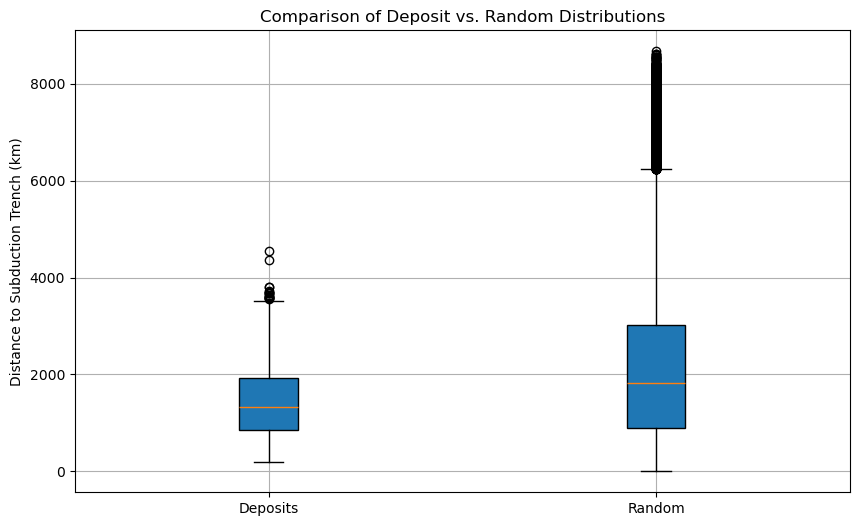

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp, mannwhitneyu, chi2_contingency
from scipy.spatial.distance import jensenshannon  # ✅ Correct JSD function
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv("deposits_VS_random.csv", low_memory=False)

# Define deposit and random columns
deposit_column = "D_ds_tr"
random_column = "R_ds_tr"
weights_column = "TM2"

# Drop NaN values for deposits and weights
valid_deposit_rows = df[deposit_column].notna() & df[weights_column].notna()
deposit_data = df.loc[valid_deposit_rows, deposit_column].values
deposit_weights = df.loc[valid_deposit_rows, weights_column].values

# Drop NaN values for random data (no weights applied)
random_data = df[random_column].dropna().values

# ✅ Kolmogorov-Smirnov Test (weights not applicable)
ks_stat, ks_pval = ks_2samp(deposit_data, random_data)

# ✅ Mann-Whitney U Test (weights not applicable)
mw_stat, mw_pval = mannwhitneyu(deposit_data, random_data, alternative="two-sided")

# ✅ Corrected Cohen’s d Calculation (Using Weighted Mean & Standard Deviation)
mean1 = np.average(deposit_data, weights=deposit_weights)
mean2 = np.mean(random_data)
var1 = np.average((deposit_data - mean1) ** 2, weights=deposit_weights)
std1 = np.sqrt(var1)
std2 = np.std(random_data, ddof=1)
pooled_std = np.sqrt((std1**2 + std2**2) / 2)
cohen_d = (mean1 - mean2) / pooled_std  # ✅ Corrected Calculation

# ✅ Corrected Jensen-Shannon Divergence Calculation
hist_deposit, _ = np.histogram(deposit_data, bins=40, weights=deposit_weights, density=True)
hist_random, _ = np.histogram(random_data, bins=40, density=True)

# Normalize to probability distributions
hist_deposit += 1e-10  # Avoid division by zero
hist_random += 1e-10
hist_deposit /= np.sum(hist_deposit)
hist_random /= np.sum(hist_random)

js_divergence = jensenshannon(hist_deposit, hist_random)  # ✅ Correct function

# ✅ Chi-Square Test using Weighted Histogram
observed = np.vstack([hist_deposit, hist_random]) * len(deposit_data)
chi2_stat, chi2_pval, _, _ = chi2_contingency(observed)

# ✅ Print results in a clean format
stats_results_weighted = {
    "Kolmogorov-Smirnov Test": {"Statistic": ks_stat, "p-value": ks_pval},
    "Mann-Whitney U Test": {"Statistic": mw_stat, "p-value": mw_pval},
    "Cohen's d (Weighted Deposits)": cohen_d,
    "Jensen-Shannon Divergence (Weighted)": js_divergence,
    "Chi-Square Test (Weighted)": {"Statistic": chi2_stat, "p-value": chi2_pval}
}

stats_df_weighted = pd.DataFrame(stats_results_weighted).T
print(stats_df_weighted)

# ✅ Visualization: Boxplots
plt.figure(figsize=(10, 6))
plt.boxplot([deposit_data, random_data], labels=["Deposits", "Random"], patch_artist=True)
plt.ylabel("Distance to Subduction Trench (km)")
plt.title("Comparison of Deposit vs. Random Distributions")
plt.grid(True)
plt.show()


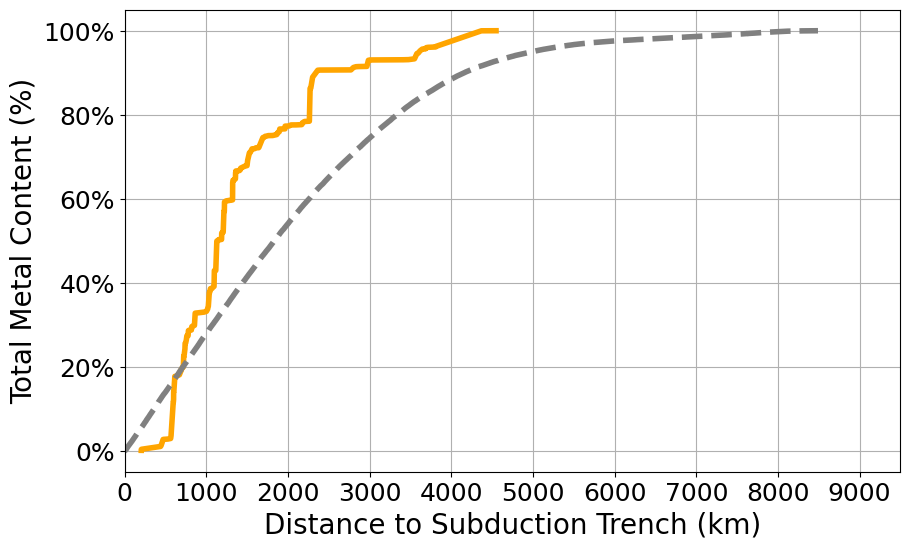

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv("deposits_VS_random.csv", low_memory=False)
df = df[(df['R_ds_tr'] >= 0) & (df['R_ds_tr'] <= 8500)]

# Define deposit and random columns
deposit_column = 'D_ds_tr'
random_column = 'R_ds_tr'
weights_column = "TM2"

# Drop NaN values for deposits and weights
valid_deposit_rows = df[deposit_column].notna() & df[weights_column].notna()
deposit_data = df.loc[valid_deposit_rows, deposit_column].values
deposit_weights = df.loc[valid_deposit_rows, weights_column].values

# Drop NaN values for random data (no weights applied)
random_data = df[random_column].dropna().values

# Ensure valid data exists before sorting
if len(deposit_data) > 0 and len(random_data) > 0:
    sorted_deposit = np.sort(deposit_data)
    sorted_random = np.sort(random_data)

    # Compute the cumulative distribution function (CDF) with weights
    cdf_deposit = np.cumsum(deposit_weights[np.argsort(deposit_data)]) / np.sum(deposit_weights)
    cdf_random = np.arange(1, len(sorted_random) + 1) / len(sorted_random)  # No weights for random data

    # Plot the cumulative distribution functions (CDF)
    plt.figure(figsize=(10, 6))
    plt.plot(sorted_deposit, cdf_deposit, label="All Deposits", color="orange", linewidth=4)
    plt.plot(sorted_random, cdf_random, label="Random Points", color="grey", linestyle="dashed", linewidth=4)

    # Labels and legend with increased font size
    plt.xlabel("Distance to Subduction Trench (km)", fontsize=20)
    plt.ylabel("Total Metal Content (%)", fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)

    # Adjust the y-axis to show percentage values correctly
    plt.yticks(np.linspace(0, 1, 6), labels=[f"{int(y*100)}%" for y in np.linspace(0, 1, 6)])

    # Ensure the x-axis starts at 0 and uses 500 km intervals up to the max random data value
    plt.xlim(0, max(max(sorted_deposit), max(sorted_random)) + 1000)
    plt.xticks(np.arange(0, max(max(sorted_deposit), max(sorted_random)) + 1000, 1000))

    #plt.legend(fontsize=18)
    plt.grid(True)

    # Show the updated plot
    plt.show()
else:
    print("Insufficient valid data for plotting.")

In [ ]:
# Trench Advance or Retreat

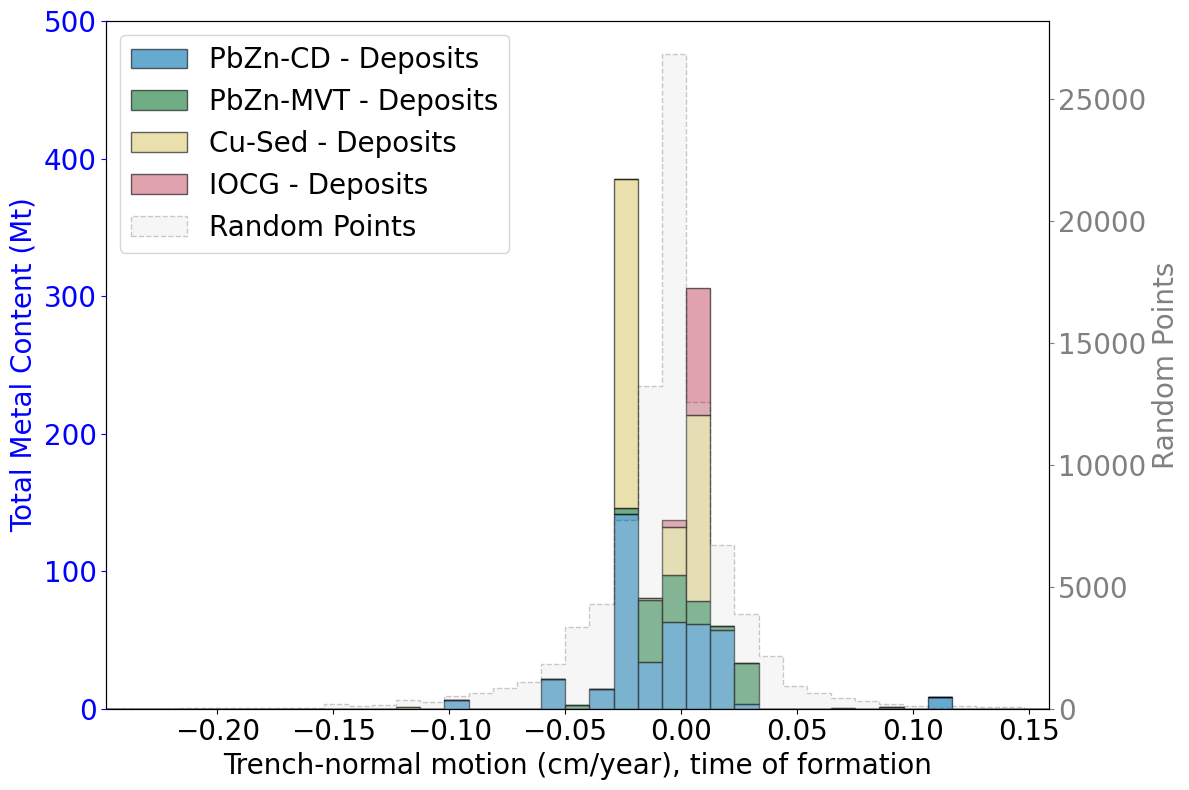

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your CSV file into a DataFrame
file_path = 'deposits_VS_random.csv'  # Update with your file path
df = pd.read_csv(file_path, low_memory=False)

# Define updated colors based on deposit type
type_colors = {
    'PbZn-CD': '#0072B2',  # Blue
    'PbZn-MVT': '#117733',  # Green
    'Cu-Sed': '#DDCC77',  # Yellow
    'IOCG': '#CC6677'  # Pink
}

# Replace NaN values in 'Type' with 'Unknown'
df['Type'] = df['Type'].fillna('Unknown')

# Function to plot stacked bar charts for deposits and separate random histograms
def plot_stacked_bar_chart_with_random(df, deposit_column, random_column, weights_column, type_colors):
    unique_types = df['Type'].unique()
    fig, ax1 = plt.subplots(figsize=(12, 8))
    ax2 = ax1.twinx()  # Create a second y-axis for the random data

    # Define consistent bin edges (using min/max of both data sets)
    min_val = df[random_column].min()  # Use minimum value of deposit data
    max_val = max(df[deposit_column].max(), df[random_column].max())
    bin_edges = np.linspace(min_val, max_val, 40)  # 40 bins for consistency
    bin_width = bin_edges[1] - bin_edges[0]

    # Initialize an array to store the bottom position for stacking
    bottom = np.zeros(len(bin_edges) - 1)

    # Plot stacked bars for each deposit type
    for deposit_type in unique_types:
        if deposit_type == 'Unknown':  # Skip the 'Unknown' type
            continue
        type_data = df[df['Type'] == deposit_type]
        deposit_data = type_data[deposit_column].dropna()
        deposit_weights = type_data[weights_column]

        if len(deposit_data) > 0:  # Only plot if there is data for this type
            counts, _ = np.histogram(deposit_data, bins=bin_edges, weights=deposit_weights[:len(deposit_data)])
            ax1.bar(
                bin_edges[:-1] + (bin_width / 2),  # Shift bars to start from 0 properly
                counts,
                width=bin_width,
                color=type_colors.get(deposit_type, 'gray'),
                alpha=0.6,
                label=f'{deposit_type} - Deposits',
                edgecolor='black',
                bottom=bottom
            )
            # Update the bottom position for the next stack
            bottom += counts

    # Plot histogram for random data on the right y-axis
    random_data = df[random_column].dropna()  # Consider all rows in the random column
    random_weights = df[weights_column].dropna()

    ax2.hist(
        random_data,
        bins=bin_edges,  # Matching bin size to make comparison meaningful
        color='lightgray',
        alpha=0.2,
        label='Random Points',
        edgecolor='black',  # Thin border for each bar
        linestyle='dashed',
        histtype='stepfilled',
        density=False  # Absolute frequency
    )

    # Customize font sizes (doubling them) and colors
    font_size = 20  # Adjusted from default ~10

    ax1.set_xlabel('Trench-normal motion (cm/year), time of formation', fontsize=font_size, color='black')  # X-axis in black
    ax1.set_ylabel('Total Metal Content (Mt)', fontsize=font_size, color='blue')  # Deposits in blue
    ax2.set_ylabel('Random Points', fontsize=font_size, color='gray')  # Random in gray

    ax1.tick_params(axis='x', labelsize=font_size, colors='black')  # X-axis in black
    ax1.tick_params(axis='y', labelsize=font_size, colors='blue')  # Deposits (left y-axis) in blue
    ax2.tick_params(axis='y', labelsize=font_size, colors='gray')  # Random (right y-axis) in gray

    ax1.set_ylim([0, 500])  # Adjust dynamically as needed
    ax1.set_xlim([min_val, max_val])  # Adjust to cover full range of data

    # Combine legends from both axes, excluding 'Unknown'
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    filtered_legend = [(line, label) for line, label in zip(lines1 + lines2, labels1 + labels2) if 'Unknown' not in label]
    filtered_lines, filtered_labels = zip(*filtered_legend) if filtered_legend else ([], [])
    ax1.legend(filtered_lines, filtered_labels, loc='upper left', fontsize=font_size)

    plt.tight_layout()
    plt.show()

# Plotting for "D_ds_tr" vs "R_ds_tr"
plot_stacked_bar_chart_with_random(
    df,
    deposit_column='D_tr_adv',
    random_column='R_tr_adv',
    weights_column='TM2',
    type_colors=type_colors
)


In [9]:
!pip install seaborn

In [ ]:
# 1

In [12]:
print(df.columns)

Index(['Type', 'TM2', 'D_cr_ve', 'D_cr_ve_az', 'D_dp_ve', 'D_sb_ve',
       'D_tr_adv', 'D_tr_cr_an', 'D_dp_ve_m', 'D_cr_ve_m', 'D_cr_ve_az_m',
       'D_tr_cr_an_m', 'D_sb_ve_m', 'D_tr_adv_m', 'D_dp_ve_diff',
       'D_cr_ve_diff', 'D_cr_ve_az_diff', 'D_tr_cr_an_diff', 'D_sb_ve_diff',
       'D_tr_adv_diff', 'D_rlat', 'D_sub_len', 'D_sub_len_m', 'D_sub_len_diff',
       'R_cr_ve_diff', 'R_cr_ve', 'R_cr_ve_az_diff', 'R_cr_ve_az',
       'R_dp_ve_diff', 'R_dp_ve', 'R_sb_ve_diff', 'R_sb_ve', 'R_tr_adv_diff',
       'R_tr_adv', 'R_tr_cr_an_diff', 'R_tr_cr_an', 'R_sub_len_diff',
       'R_sub_len', 'R_rlat', 'R_cr_ve_m', 'R_cr_ve_az_m', 'R_dp_ve_m',
       'R_sb_ve_m', 'R_tr_adv_m', 'R_tr_cr_an_m', 'R_sub_len_m'],
      dtype='object')


# Scatterplots

# 3-axis stacked bar chart

# swap axes

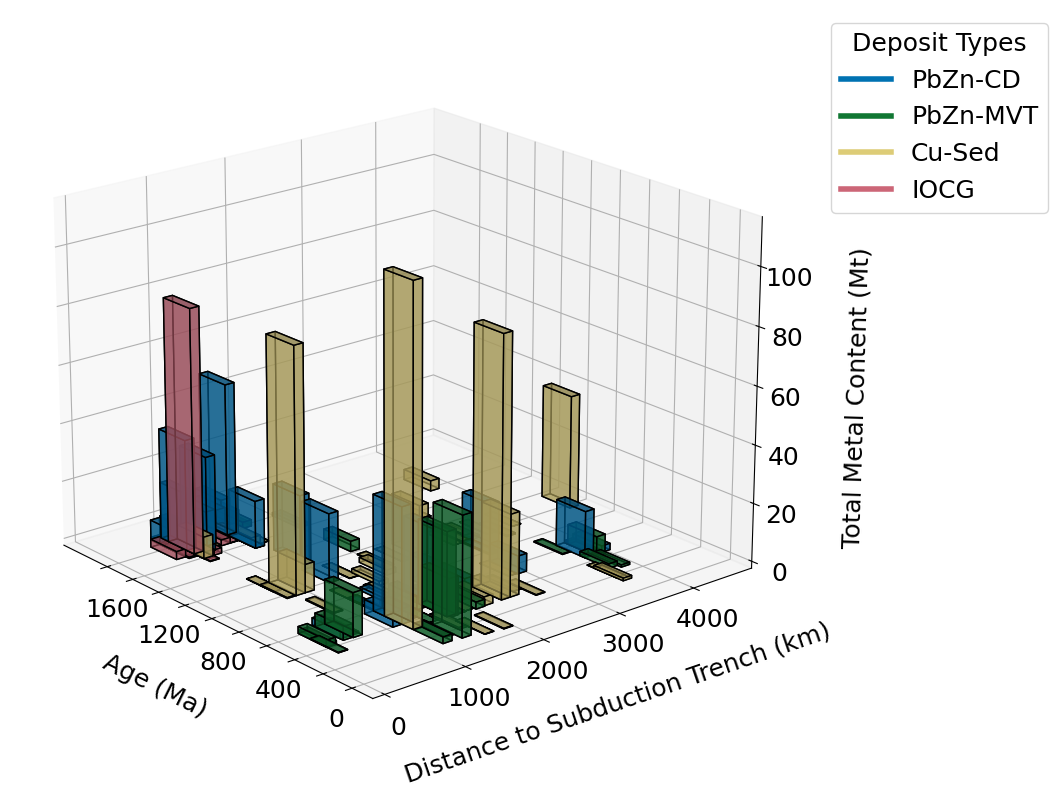

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
file_path = './deposits_VS_random.csv'  # Replace with your file path
data = pd.read_csv(file_path, low_memory=False)

# Remove rows with NaN values in relevant columns
filtered_data = data.dropna(subset=['D_ds_tr', 'Age', 'TM2', 'Type'])

# Define custom colors
custom_colors = ['#0072B2', '#117733', '#DDCC77', '#CC6677']

# Set bin size exactly as provided
previous_min_val = 0  # Start from 0
previous_max_val = filtered_data['D_ds_tr'].max()
num_bins = 40  # Same number of bins as in previous charts
bin_edges = np.linspace(previous_min_val, previous_max_val, num_bins + 1)  # Ensure 40 bins
bin_widths = np.diff(bin_edges)  # Calculate bin widths dynamically
y_positions = (bin_edges[:-1] + bin_edges[1:]) / 2  # Center of each bin

# Prepare X-axis intervals with steps of 200 for Age
x_ticks = np.arange(0, filtered_data['Age'].max() + 200, 200)

# Remove every other label from Age axis (X-axis)
x_labels = [int(x) if i % 2 == 0 else '' for i, x in enumerate(x_ticks)]

# Create the 3D bar chart
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Adjust the view angle
ax.view_init(elev=20, azim=-40)

# Map deposit types to custom colors
deposit_types = filtered_data['Type'].unique()
type_color_mapping = {deposit_type: custom_colors[i % len(custom_colors)] for i, deposit_type in enumerate(deposit_types)}

# Iterate through ages (X-axis now) and distances (Y-axis) to plot bars
for j, age in enumerate(filtered_data['Age'].unique()):
    for i in range(len(bin_edges) - 1):
        subset = filtered_data[(filtered_data['D_ds_tr'] >= bin_edges[i]) &
                               (filtered_data['D_ds_tr'] < bin_edges[i + 1]) &
                               (filtered_data['Age'] == age)]
        if not subset.empty:
            weighted_count = subset['TM2'].sum()  # Sum of weights for the number of deposits
            deposit_type = subset['Type'].iloc[0]  # Get the deposit type for the subset
            ax.bar3d(
                age, y_positions[i], 0,  # Swapped X (Age) and Y (Distance)
                200, bin_widths[i], weighted_count,  # Width (Age), Depth (Distance), Height
                color=type_color_mapping[deposit_type],  # Mapped color
                edgecolor='k',  # Add black edges to bars
                alpha=0.6,  # Transparency
                shade=True
            )

# Add legend with doubled font sizes
legend_handles = [
    plt.Line2D([0], [0], color=type_color_mapping[deposit_type], lw=4, label=deposit_type)
    for deposit_type in deposit_types
]
legend = ax.legend(handles=legend_handles, title="Deposit Types", loc="upper left", 
                    bbox_to_anchor=(1.05, 1), fontsize=18, title_fontsize=18)  # Doubled font sizes

# Customize the chart with swapped axes
ax.set_xlabel('Age (Ma)', fontsize=18, labelpad=20)
ax.set_ylabel('Distance to Subduction Trench (km)', fontsize=18, labelpad=20)
ax.set_zlabel('Total Metal Content (Mt)', fontsize=18, labelpad=20)

# Update Age axis ticks and remove every other label
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=18)

ax.tick_params(axis='both', labelsize=18)

# Invert Age axis to start from the other side
ax.invert_xaxis()

# Title removed for a cleaner look
plt.show()


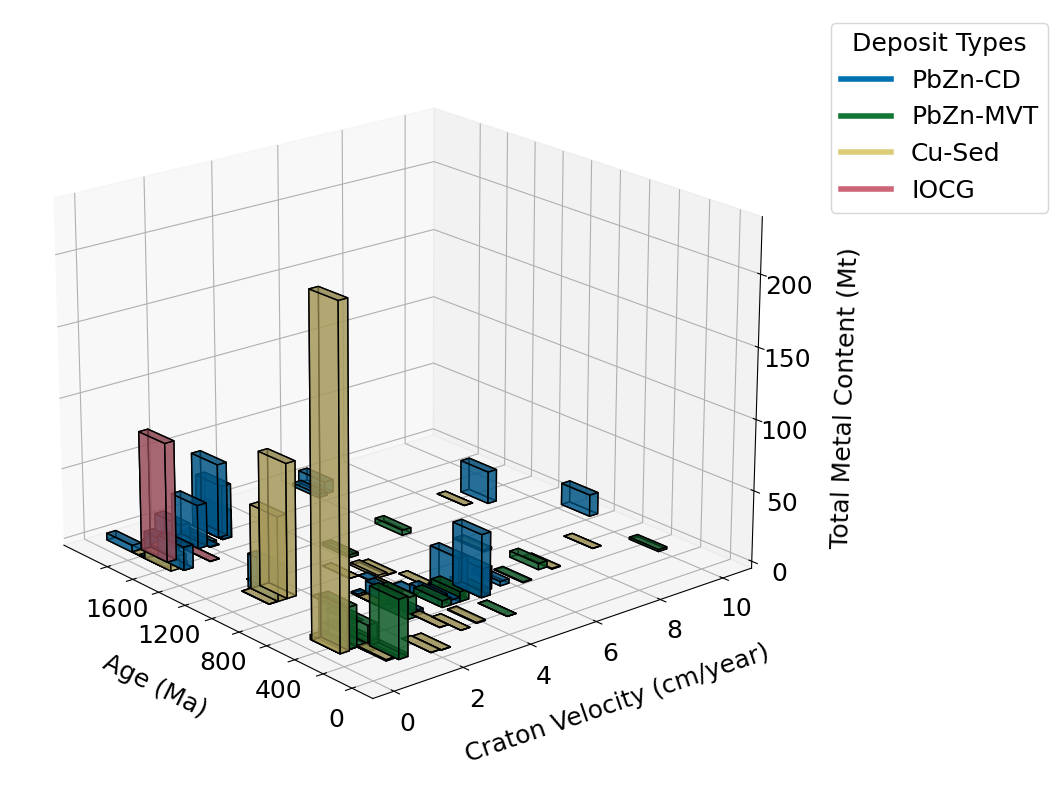

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Value = 'D_cr_ve'

# Load the dataset
file_path = './deposits_VS_random.csv'  # Replace with your file path
data = pd.read_csv(file_path, low_memory=False)

# Remove rows with NaN values in relevant columns
filtered_data = data.dropna(subset=[Value, 'Age', 'TM2', 'Type'])

# Define custom colors
custom_colors = ['#0072B2', '#117733', '#DDCC77', '#CC6677']

# Set bin size exactly as provided
previous_min_val = 0  # Start from 0
previous_max_val = filtered_data[Value].max()
num_bins = 40  # Same number of bins as in previous charts
bin_edges = np.linspace(previous_min_val, previous_max_val, num_bins + 1)  # Ensure 40 bins
bin_widths = np.diff(bin_edges)  # Calculate bin widths dynamically
y_positions = (bin_edges[:-1] + bin_edges[1:]) / 2  # Center of each bin

# Prepare X-axis intervals with steps of 200 for Age
x_ticks = np.arange(0, filtered_data['Age'].max() + 200, 200)

# Remove every other label from Age axis (X-axis)
x_labels = [int(x) if i % 2 == 0 else '' for i, x in enumerate(x_ticks)]

# Create the 3D bar chart
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Adjust the view angle
ax.view_init(elev=20, azim=-40)

# Map deposit types to custom colors
deposit_types = filtered_data['Type'].unique()
type_color_mapping = {deposit_type: custom_colors[i % len(custom_colors)] for i, deposit_type in enumerate(deposit_types)}

# Iterate through ages (X-axis now) and craton velocities (Y-axis) to plot bars
for j, age in enumerate(filtered_data['Age'].unique()):
    for i in range(len(bin_edges) - 1):
        subset = filtered_data[(filtered_data[Value] >= bin_edges[i]) &
                               (filtered_data[Value] < bin_edges[i + 1]) &
                               (filtered_data['Age'] == age)]
        if not subset.empty:
            weighted_count = subset['TM2'].sum()  # Sum of weights for the number of deposits
            deposit_type = subset['Type'].iloc[0]  # Get the deposit type for the subset
            ax.bar3d(
                age, y_positions[i], 0,  # Swapped X (Age) and Y (Craton Velocity)
                200, bin_widths[i], weighted_count,  # Width (Age), Depth (Craton Velocity), Height
                color=type_color_mapping[deposit_type],  # Mapped color
                edgecolor='k',  # Add black edges to bars
                alpha=0.6,  # Transparency
                shade=True
            )

# Add legend with doubled font sizes
legend_handles = [
    plt.Line2D([0], [0], color=type_color_mapping[deposit_type], lw=4, label=deposit_type)
    for deposit_type in deposit_types
]
legend = ax.legend(handles=legend_handles, title="Deposit Types", loc="upper left", 
                    bbox_to_anchor=(1.05, 1), fontsize=18, title_fontsize=18)  # Doubled font sizes

# Customize the chart with swapped axes
ax.set_xlabel('Age (Ma)', fontsize=18, labelpad=20)
ax.set_ylabel('Craton Velocity (cm/year)', fontsize=18, labelpad=20)
ax.set_zlabel('Total Metal Content (Mt)', fontsize=18, labelpad=15)

# Update Age axis ticks and remove every other label
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=18)

ax.tick_params(axis='both', labelsize=18)

# Invert Age axis to start from the other side
ax.invert_xaxis()

# Title removed for a cleaner look
plt.show()


In [ ]:
# subduction length

In [57]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# Value = 'D_sub_len'

# # Load the dataset
# file_path = './deposits_VS_random.csv'  # Replace with your file path
# data = pd.read_csv(file_path, low_memory=False)

# # Remove rows with NaN values in relevant columns
# filtered_data = data.dropna(subset=[Value, 'Age', 'TM2', 'Type'])

# # Define custom colors
# custom_colors = ['#0072B2', '#117733', '#DDCC77', '#CC6677']

# # Set bin size exactly as provided
# previous_min_val = 0  # Start from 0
# previous_max_val = filtered_data[Value].max()
# num_bins = 40  # Same number of bins as in previous charts
# bin_edges = np.linspace(previous_min_val, previous_max_val, num_bins + 1)  # Ensure 40 bins
# bin_widths = np.diff(bin_edges)  # Calculate bin widths dynamically
# y_positions = (bin_edges[:-1] + bin_edges[1:]) / 2  # Center of each bin

# # Prepare X-axis intervals with steps of 200 for Age
# x_ticks = np.arange(0, filtered_data['Age'].max() + 200, 200)

# # Remove every other label from Age axis (X-axis)
# x_labels = [int(x) if i % 2 == 0 else '' for i, x in enumerate(x_ticks)]

# # Create the 3D bar chart
# fig = plt.figure(figsize=(14, 10))
# ax = fig.add_subplot(111, projection='3d')

# # Adjust the view angle
# ax.view_init(elev=20, azim=-40)

# # Map deposit types to custom colors
# deposit_types = filtered_data['Type'].unique()
# type_color_mapping = {deposit_type: custom_colors[i % len(custom_colors)] for i, deposit_type in enumerate(deposit_types)}

# # Iterate through ages (X-axis now) and subduction lengths (Y-axis) to plot bars
# for j, age in enumerate(filtered_data['Age'].unique()):
#     for i in range(len(bin_edges) - 1):
#         subset = filtered_data[(filtered_data[Value] >= bin_edges[i]) &
#                                (filtered_data[Value] < bin_edges[i + 1]) &
#                                (filtered_data['Age'] == age)]
#         if not subset.empty:
#             weighted_count = subset['TM2'].sum()  # Sum of weights for the number of deposits
#             deposit_type = subset['Type'].iloc[0]  # Get the deposit type for the subset
#             ax.bar3d(
#                 age, y_positions[i], 0,  # Swapped X (Age) and Y (Subduction Length)
#                 200, bin_widths[i], weighted_count,  # Width (Age), Depth (Subduction), Height
#                 color=type_color_mapping[deposit_type],  # Mapped color
#                 edgecolor='k',  # Add black edges to bars
#                 alpha=0.6,  # Transparency
#                 shade=True
#             )

# # Add legend with doubled font sizes
# legend_handles = [
#     plt.Line2D([0], [0], color=type_color_mapping[deposit_type], lw=4, label=deposit_type)
#     for deposit_type in deposit_types
# ]
# legend = ax.legend(handles=legend_handles, title="Deposit Types", loc="upper left", 
#                     bbox_to_anchor=(1.05, 1), fontsize=18, title_fontsize=18)  # Doubled font sizes

# # Customize the chart with swapped axes
# ax.set_xlabel('Age (Ma)', fontsize=18, labelpad=20)
# ax.set_ylabel('Subduction Length (km)', fontsize=18, labelpad=20)
# ax.set_zlabel('Total Metal Content (Mt)', fontsize=18, labelpad=15)

# # Update Age axis ticks and remove every other label
# ax.set_xticks(x_ticks)
# ax.set_xticklabels(x_labels, fontsize=18)

# ax.tick_params(axis='both', labelsize=14)

# # Invert Age axis to start from the other side
# ax.invert_xaxis()

# # Title removed for a cleaner look
# plt.show()


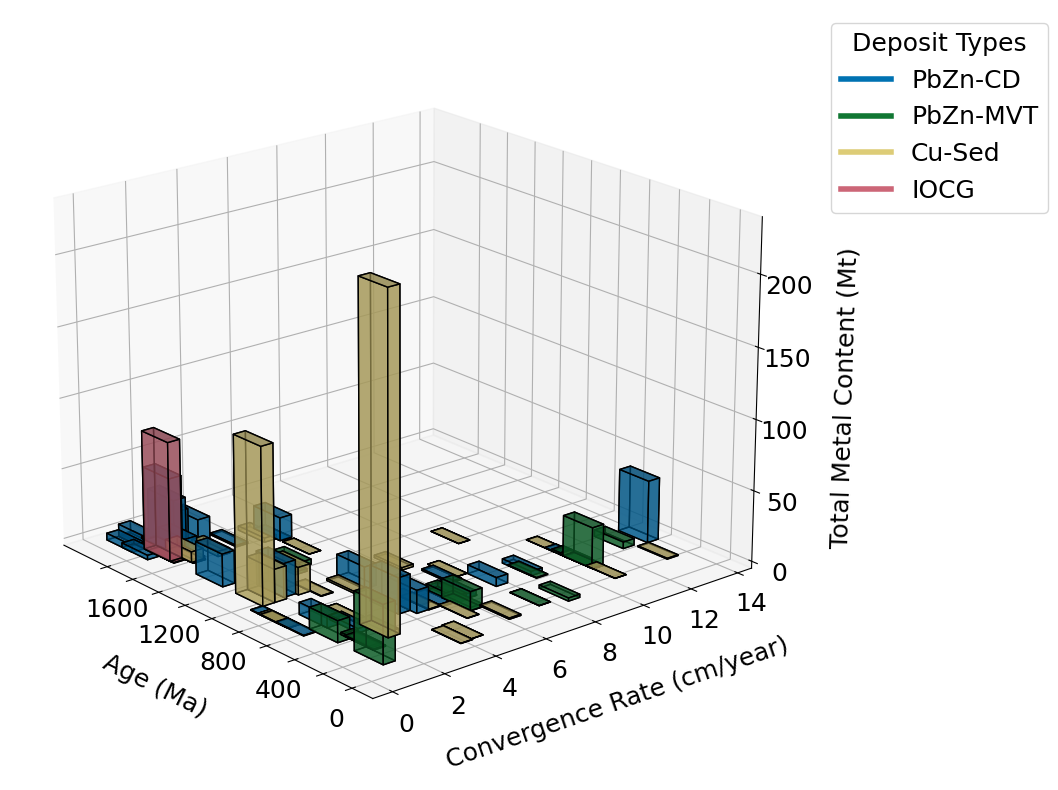

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Value = 'D_sb_ve'

# Load the dataset
file_path = './deposits_VS_random.csv'  # Replace with your file path
data = pd.read_csv(file_path, low_memory=False)

# Remove rows with NaN values in relevant columns
filtered_data = data.dropna(subset=[Value, 'Age', 'TM2', 'Type'])

# Define custom colors
custom_colors = ['#0072B2', '#117733', '#DDCC77', '#CC6677']

# Set bin size exactly as provided
min_val = 0  # Explicitly start from 0
max_val = filtered_data[Value].max()
num_bins = 40  # Same number of bins as in previous charts
bin_edges = np.linspace(min_val, max_val, num_bins + 1)  # Ensure 40 bins
bin_widths = np.diff(bin_edges)  # Calculate bin widths dynamically
y_positions = (bin_edges[:-1] + bin_edges[1:]) / 2  # Center of each bin

# Prepare X-axis intervals with steps of 200 for Age
x_ticks = np.arange(0, filtered_data['Age'].max() + 200, 200)

# Remove every other label from Age axis (X-axis)
x_labels = [int(x) if i % 2 == 0 else '' for i, x in enumerate(x_ticks)]

# Create the 3D bar chart
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Adjust the view angle
ax.view_init(elev=20, azim=-40)

# Map deposit types to custom colors
deposit_types = filtered_data['Type'].unique()
type_color_mapping = {deposit_type: custom_colors[i % len(custom_colors)] for i, deposit_type in enumerate(deposit_types)}

# Iterate through ages (X-axis now) and convergence rates (Y-axis) to plot bars
for j, age in enumerate(filtered_data['Age'].unique()):
    for i in range(len(bin_edges) - 1):
        subset = filtered_data[(filtered_data[Value] >= bin_edges[i]) &
                               (filtered_data[Value] < bin_edges[i + 1]) &
                               (filtered_data['Age'] == age)]
        if not subset.empty:
            weighted_count = subset['TM2'].sum()  # Sum of weights for the number of deposits
            deposit_type = subset['Type'].iloc[0]  # Get the deposit type for the subset
            ax.bar3d(
                age, y_positions[i], 0,  # Swapped X (Age) and Y (Convergence Rate)
                200, bin_widths[i], weighted_count,  # Width (Age), Depth (Convergence Rate), Height
                color=type_color_mapping[deposit_type],  # Mapped color
                edgecolor='k',  # Add black edges to bars
                alpha=0.6,  # Transparency
                shade=True
            )

# Add legend with doubled font sizes
legend_handles = [
    plt.Line2D([0], [0], color=type_color_mapping[deposit_type], lw=4, label=deposit_type)
    for deposit_type in deposit_types
]
legend = ax.legend(handles=legend_handles, title="Deposit Types", loc="upper left", 
                    bbox_to_anchor=(1.05, 1), fontsize=18, title_fontsize=18)  # Doubled font sizes

# Customize the chart with swapped axes
ax.set_xlabel('Age (Ma)', fontsize=18, labelpad=20)
ax.set_ylabel('Convergence Rate (cm/year)', fontsize=18, labelpad=20)
ax.set_zlabel('Total Metal Content (Mt)', fontsize=18, labelpad=15)

# Update Age axis ticks and remove every other label
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=18)

ax.tick_params(axis='both', labelsize=18)

# Invert Age axis to start from the other side
ax.invert_xaxis()

# Title removed for a cleaner look
plt.show()


In [7]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# Value = 'D_tr_adv'

# # Load the dataset
# file_path = './deposits_VS_random.csv'  # Replace with your file path
# data = pd.read_csv(file_path, low_memory=False)

# # Remove rows with NaN values in relevant columns
# filtered_data = data.dropna(subset=[Value, 'Age', 'TM2', 'Type'])

# # Define custom colors
# custom_colors = ['#0072B2', '#117733', '#DDCC77', '#CC6677']

# # Set bin size exactly as provided
# min_val = 0  # Explicitly start from 0
# max_val = filtered_data[Value].max()
# num_bins = 40  # Same number of bins as in previous charts
# bin_edges = np.linspace(min_val, max_val, num_bins + 1)  # Ensure 40 bins
# bin_widths = np.diff(bin_edges)  # Calculate bin widths dynamically
# y_positions = (bin_edges[:-1] + bin_edges[1:]) / 2  # Center of each bin

# # Prepare X-axis intervals with steps of 200 for Age
# x_ticks = np.arange(0, filtered_data['Age'].max() + 200, 200)

# # Remove every other label from Age axis (X-axis)
# x_labels = [int(x) if i % 2 == 0 else '' for i, x in enumerate(x_ticks)]

# # Create the 3D bar chart
# fig = plt.figure(figsize=(14, 10))
# ax = fig.add_subplot(111, projection='3d')

# # Adjust the view angle
# ax.view_init(elev=20, azim=-40)

# # Map deposit types to custom colors
# deposit_types = filtered_data['Type'].unique()
# type_color_mapping = {deposit_type: custom_colors[i % len(custom_colors)] for i, deposit_type in enumerate(deposit_types)}

# # Iterate through ages (X-axis now) and convergence rates (Y-axis) to plot bars
# for j, age in enumerate(filtered_data['Age'].unique()):
#     for i in range(len(bin_edges) - 1):
#         subset = filtered_data[(filtered_data[Value] >= bin_edges[i]) &
#                                (filtered_data[Value] < bin_edges[i + 1]) &
#                                (filtered_data['Age'] == age)]
#         if not subset.empty:
#             weighted_count = subset['TM2'].sum()  # Sum of weights for the number of deposits
#             deposit_type = subset['Type'].iloc[0]  # Get the deposit type for the subset
#             ax.bar3d(
#                 age, y_positions[i], 0,  # Swapped X (Age) and Y (Convergence Rate)
#                 200, bin_widths[i], weighted_count,  # Width (Age), Depth (Convergence Rate), Height
#                 color=type_color_mapping[deposit_type],  # Mapped color
#                 edgecolor='k',  # Add black edges to bars
#                 alpha=0.6,  # Transparency
#                 shade=True
#             )

# # Add legend with doubled font sizes
# legend_handles = [
#     plt.Line2D([0], [0], color=type_color_mapping[deposit_type], lw=4, label=deposit_type)
#     for deposit_type in deposit_types
# ]
# legend = ax.legend(handles=legend_handles, title="Deposit Types", loc="upper left", 
#                     bbox_to_anchor=(1.05, 1), fontsize=18, title_fontsize=18)  # Doubled font sizes

# # Customize the chart with swapped axes
# ax.set_xlabel('Age (Ma)', fontsize=18, labelpad=20)
# ax.set_ylabel('Trench-normal motion (cm/year)', fontsize=18, labelpad=20)
# ax.set_zlabel('Total Metal Content (Mt)', fontsize=18, labelpad=15)

# # Update Age axis ticks and remove every other label
# ax.set_xticks(x_ticks)
# ax.set_xticklabels(x_labels, fontsize=18)

# ax.tick_params(axis='both', labelsize=18)

# # Invert Age axis to start from the other side
# ax.invert_xaxis()

# # Title removed for a cleaner look
# plt.show()


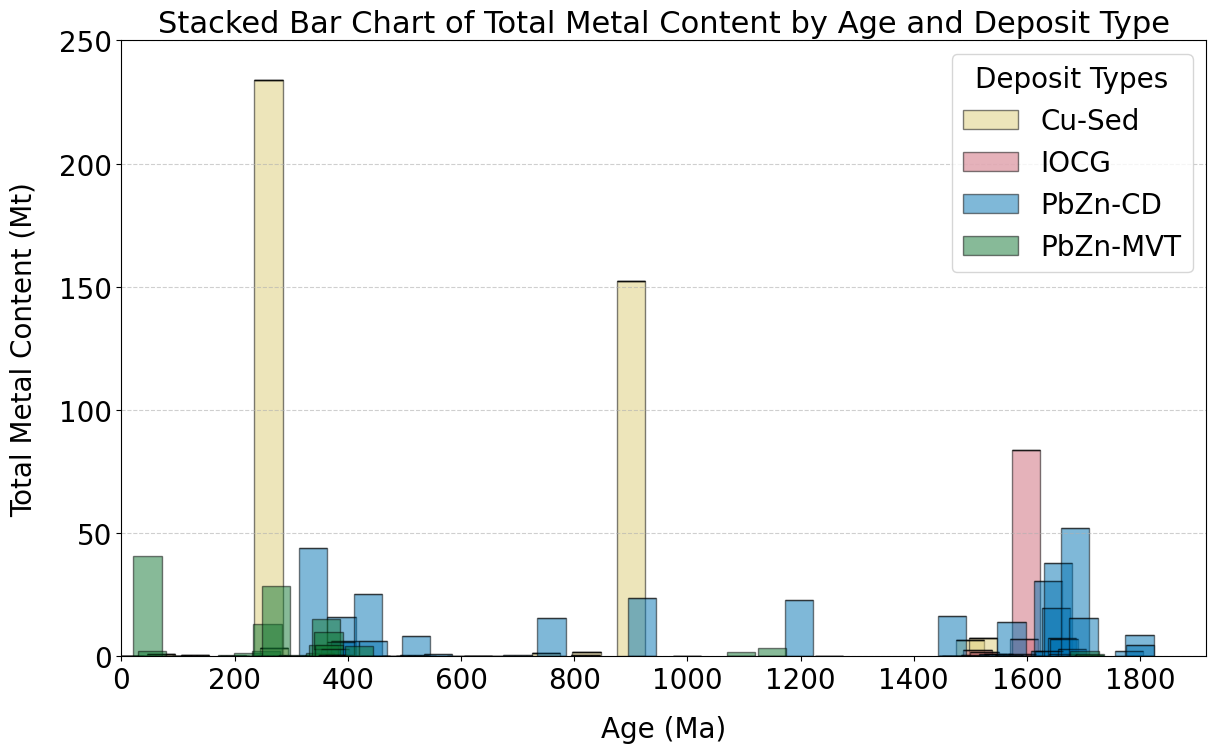

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your CSV file into a DataFrame
file_path = 'deposits_VS_random.csv'  # Update with your file path
df = pd.read_csv(file_path, low_memory=False)

# Define colors based on deposit type
type_colors = {
    'PbZn-CD': '#0072B2',  # Blue
    'PbZn-MVT': '#117733',  # Green
    'Cu-Sed': '#DDCC77',    # Yellow
    'IOCG': '#CC6677'       # Pink
}

# Replace NaN values in 'Type' with 'Unknown'
df['Type'] = df['Type'].fillna('Unknown')

# Remove NaN values in relevant columns
df = df.dropna(subset=['Age', 'TM2', 'Type'])

# Group data by Age and Type, summing the Total Metal Content
grouped_data = df.groupby(['Age', 'Type'])['TM2'].sum().unstack(fill_value=0)

# Sort by Age (to start from 0 Ma on the left)
grouped_data = grouped_data.sort_index()

# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(14, 8))

# X positions for bars (Age values)
x_positions = grouped_data.index

# Initialize the bottom array for stacking
bottom_values = np.zeros(len(grouped_data))

# Plot each deposit type as a stacked bar with transparency
for i, deposit_type in enumerate(grouped_data.columns):
    color = type_colors.get(deposit_type, 'gray')
    ax.bar(
        x_positions, grouped_data[deposit_type], 
        bottom=bottom_values, color=color, label=deposit_type, 
        edgecolor='black', width=50, alpha=0.5  # Added transparency (alpha=0.5)
    )
    bottom_values += grouped_data[deposit_type]  # Stack on top

# Customize X-axis ticks (Age) with intervals of 200 Ma and remove decimals
x_ticks = np.arange(0, grouped_data.index.max() + 200, 200)
ax.set_xticks(x_ticks)
ax.set_xticklabels([int(tick) for tick in x_ticks], fontsize=20)  # No decimals, doubled font size

# Customize Y-axis ticks (Total Metal Content) with intervals of 50 Mt and remove decimals
y_max = bottom_values.max()
y_ticks = np.arange(0, y_max + 50, 50)
ax.set_yticks(y_ticks)
ax.set_yticklabels([int(tick) for tick in y_ticks], fontsize=20)  # No decimals, doubled font size

# Customize plot
ax.set_xlabel('Age (Ma)', fontsize=20, labelpad=15)
ax.set_ylabel('Total Metal Content (Mt)', fontsize=20, labelpad=15)
ax.set_title('Stacked Bar Chart of Total Metal Content by Age and Deposit Type', fontsize=22)
ax.legend(title='Deposit Types', fontsize=20, title_fontsize=20)  # Doubled legend font size
ax.grid(axis='y', linestyle='--', alpha=0.6)

# X-axis starts at 0 and increases (0 on the left)
ax.set_xlim(left=0)

plt.show()


# Density for Rnadom

# Modified

C:\Users\Hojat\AppData\Local\Temp\ipykernel_3536\2057711478.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


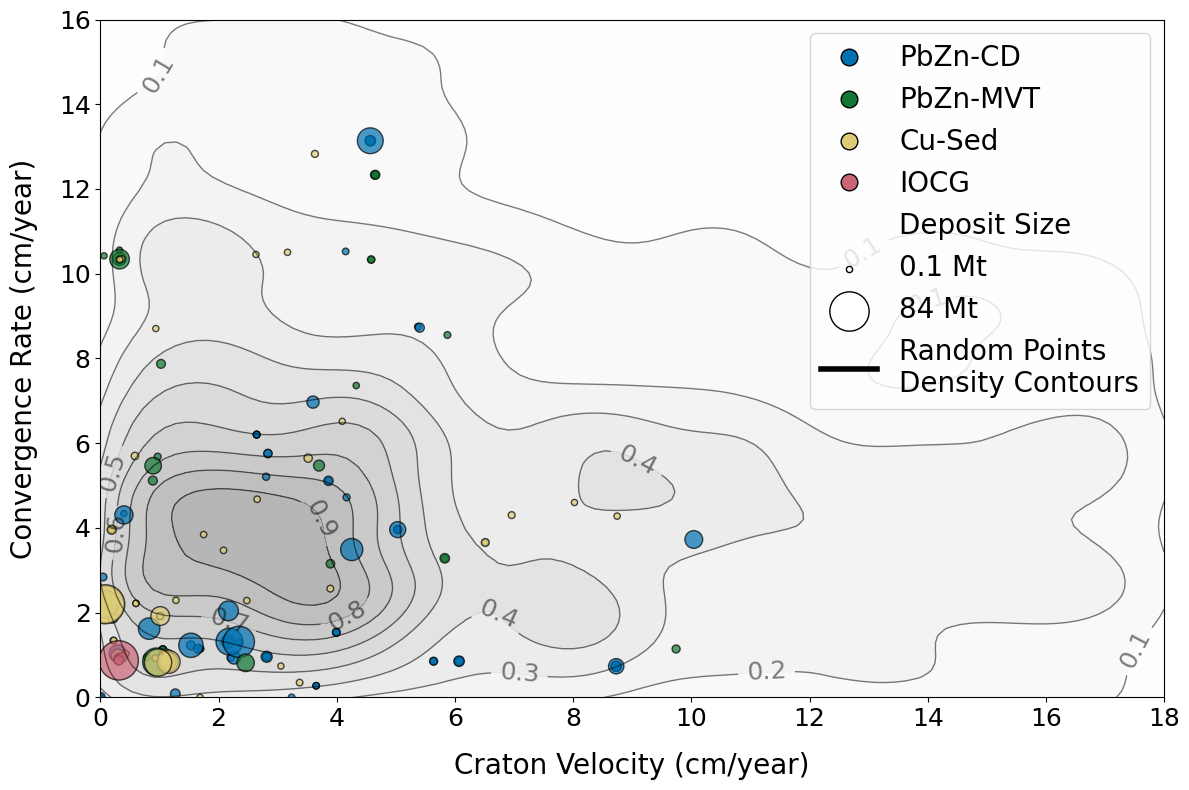

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Load your CSV file into a DataFrame
file_path = 'deposits_VS_random.csv'  # Update with your file path
df = pd.read_csv(file_path)

# Define columns for deposit and random data
x_deposit = 'D_cr_ve'
y_deposit = 'D_sb_ve'
x_random = 'R_cr_ve'
y_random = 'R_sb_ve'
weights_column = 'TM2'

# Select data without filtering NaN
deposit_data = df[[x_deposit, y_deposit, weights_column, 'Type']]
random_data = df[[x_random, y_random]]

# Remove negative values
deposit_data = deposit_data[(deposit_data[x_deposit] >= 0) & (deposit_data[y_deposit] >= 0)]
random_data = random_data[(random_data[x_random] >= 0) & (random_data[y_random] >= 0)]

# Extract data and weights
x_deposit_values = deposit_data[x_deposit]
y_deposit_values = deposit_data[y_deposit]
deposit_weights = deposit_data[weights_column]
deposit_types = deposit_data['Type']

x_random_values = random_data[x_random]
y_random_values = random_data[y_random]

# Define colors based on deposit type
type_colors = {
    'PbZn-CD': '#0072B2',  # Blue
    'PbZn-MVT': '#117733',  # Green
    'Cu-Sed': '#DDCC77',  # Yellow
    'IOCG': '#CC6677',  # Pink
    'Unknown': 'gray'  # For any NaN or unknown types
}

# Map TM2 to size using a continuous scale
min_size, max_size = 20, 800  # Minimum and maximum sizes for scaling
scaled_sizes = (deposit_weights - deposit_weights.min()) / (deposit_weights.max() - deposit_weights.min())
scaled_sizes = scaled_sizes * (max_size - min_size) + min_size

# Compute density contours for random points
xmin, xmax = 0, 18
ymin, ymax = 0, 16
xx, yy = np.meshgrid(np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100))

# Compute KDE for random points
values = np.vstack([x_random_values, y_random_values])
kde = gaussian_kde(values)
density = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

# Normalize density values to range between 0 and 1
density_normalized = density / density.max()

# Create plot
plt.figure(figsize=(12, 8))

# Plot filled gray contour for random points
contour = plt.contourf(xx, yy, density_normalized, levels=10, cmap='Greys', alpha=0.3)
cset = plt.contour(xx, yy, density_normalized, levels=10, colors='black', linewidths=1, alpha=0.5)

# Ensure contour labels are meaningful
plt.clabel(cset, inline=True, fontsize=18, fmt="%.1f")  # **Larger contour labels**

# Scatter plot for deposits with continuous scaling, colored by type
for deposit_type in deposit_types.unique():
    if pd.isna(deposit_type) or deposit_type == 'Unknown':
        continue
    type_data = deposit_data[deposit_data['Type'] == deposit_type]
    plt.scatter(type_data[x_deposit], type_data[y_deposit],
                s=scaled_sizes[type_data.index],
                color=type_colors.get(deposit_type, 'gray'),
                edgecolor='black',
                alpha=0.7, label=f'{deposit_type}', marker='o')

# Add placeholders for Deposit Types and Deposit Size
legend_elements = []
for deposit_type, color in type_colors.items():
    if deposit_type != 'Unknown':  # Keep all deposit types
        legend_elements.append(plt.Line2D([0], [0], marker='o', color=color, label=deposit_type, markersize=12, 
                                          markeredgecolor='black', linestyle='None'))

# Add Deposit Size section
legend_elements.append(plt.Line2D([0], [0], label='Deposit Size', color='none', markersize=20))
legend_elements.append(plt.scatter([], [], s=min_size, color='white', alpha=1, edgecolor='black', label='0.1 Mt', marker='o'))
legend_elements.append(plt.scatter([], [], s=max_size, color='white', alpha=1, edgecolor='black', label='84 Mt', marker='o'))

# Add legend entry for random point density contours (Split into two rows)
legend_elements.append(plt.Line2D([0], [0], color='black', linewidth=4, 
                                  label='Random Points\nDensity Contours'))  # Two-line label

# Set axis limits
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])

# Labels and legend
plt.xlabel('Craton Velocity (cm/year)', fontsize=20, labelpad=15)
plt.ylabel('Convergence Rate (cm/year)', fontsize=20, labelpad=15)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Adjust the legend with **tighter line spacing**
plt.legend(handles=legend_elements, loc='upper right', frameon=True, labelspacing=0.5,  # **Tighter line spacing**
           fontsize=20, title_fontsize=20, title="")  # Empty title removes "Deposit Types"

#plt.title('Density Contours of Random Points with Deposits', fontsize=22)
plt.tight_layout()
plt.show()


C:\Users\Hojat\AppData\Local\Temp\ipykernel_596\3927815829.py:9: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


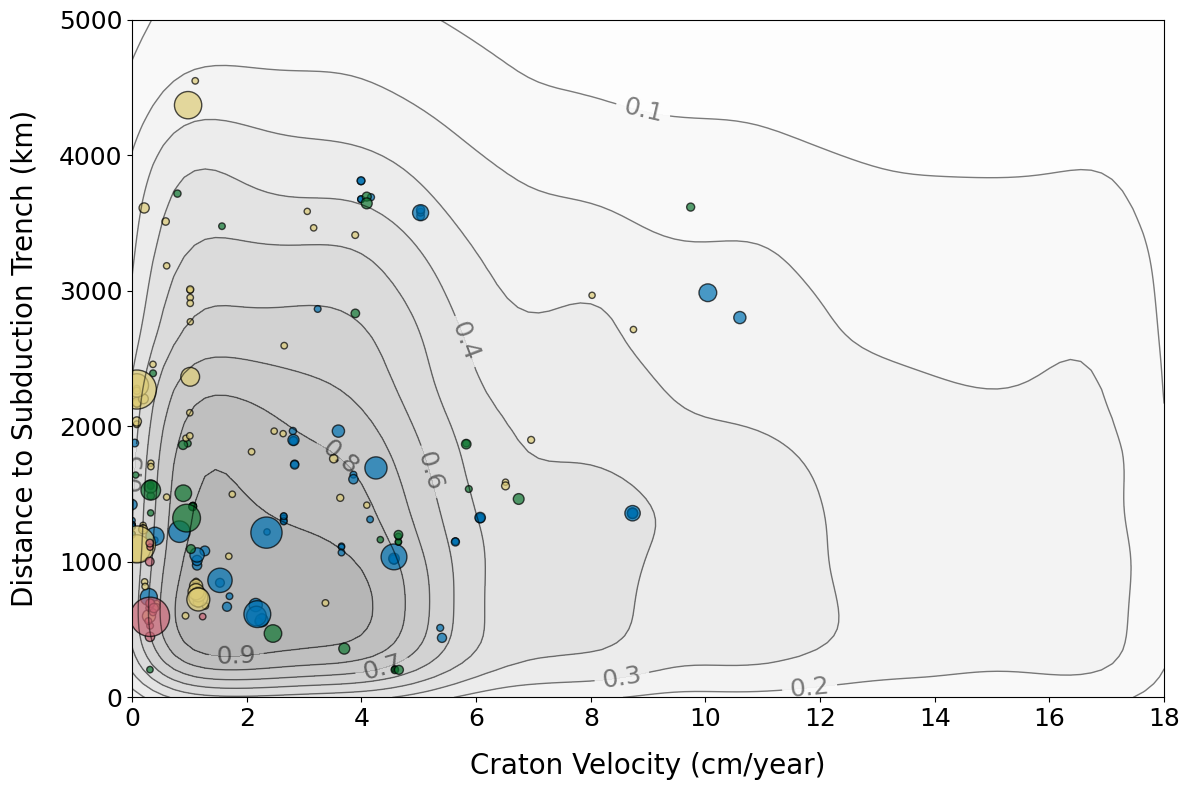

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Load your CSV file into a DataFrame
file_path = 'deposits_VS_random.csv'  # Update with your file path
df = pd.read_csv(file_path)

# Define columns for deposit and random data
x_deposit = 'D_cr_ve'
y_deposit = 'D_ds_tr'
x_random = 'R_cr_ve'
y_random = 'R_ds_tr'
weights_column = 'TM2'

# Select data without filtering NaN
deposit_data = df[[x_deposit, y_deposit, weights_column, 'Type']]
random_data = df[[x_random, y_random]]

# Remove negative values
deposit_data = deposit_data[(deposit_data[x_deposit] >= 0) & (deposit_data[y_deposit] >= 0)]
random_data = random_data[(random_data[x_random] >= 0) & (random_data[y_random] >= 0)]

# Extract data and weights
x_deposit_values = deposit_data[x_deposit]
y_deposit_values = deposit_data[y_deposit]
deposit_weights = deposit_data[weights_column]
deposit_types = deposit_data['Type']

x_random_values = random_data[x_random]
y_random_values = random_data[y_random]

# Define colors based on deposit type
type_colors = {
    'PbZn-CD': '#0072B2',  # Blue
    'PbZn-MVT': '#117733',  # Green
    'Cu-Sed': '#DDCC77',  # Yellow
    'IOCG': '#CC6677',  # Pink
    'Unknown': 'gray'  # For any NaN or unknown types
}

# Map TM2 to size using a continuous scale
min_size, max_size = 20, 800  # Minimum and maximum sizes for scaling
scaled_sizes = (deposit_weights - deposit_weights.min()) / (deposit_weights.max() - deposit_weights.min())
scaled_sizes = scaled_sizes * (max_size - min_size) + min_size

# Compute density contours for random points
xmin, xmax = 0, 18
ymin, ymax = 0, 5000
xx, yy = np.meshgrid(np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100))

# Compute KDE for random points
values = np.vstack([x_random_values, y_random_values])
kde = gaussian_kde(values)
density = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

# Normalize density values to range between 0 and 1
density_normalized = density / density.max()

# Create plot
plt.figure(figsize=(12, 8))

# Plot filled gray contour for random points
contour = plt.contourf(xx, yy, density_normalized, levels=10, cmap='Greys', alpha=0.3)
cset = plt.contour(xx, yy, density_normalized, levels=10, colors='black', linewidths=1, alpha=0.5)

# Ensure contour labels are readable
plt.clabel(cset, inline=True, fontsize=18, fmt="%.1f")  # **Larger contour labels**

# Scatter plot for deposits with continuous scaling, colored by type
for deposit_type in deposit_types.unique():
    if pd.isna(deposit_type) or deposit_type == 'Unknown':
        continue
    type_data = deposit_data[deposit_data['Type'] == deposit_type]
    plt.scatter(type_data[x_deposit], type_data[y_deposit],
                s=scaled_sizes[type_data.index],
                color=type_colors.get(deposit_type, 'gray'),
                edgecolor='black',
                alpha=0.7, label=f'{deposit_type}', marker='o')

# Add placeholders for Deposit Types and Deposit Size
legend_elements = []
for deposit_type, color in type_colors.items():
    if deposit_type != 'Unknown':  # Keep all deposit types
        legend_elements.append(plt.Line2D([0], [0], marker='o', color=color, label=deposit_type, markersize=12, 
                                          markeredgecolor='black', linestyle='None'))

# Add Deposit Size section
legend_elements.append(plt.Line2D([0], [0], label='Deposit Size', color='none', markersize=20))
legend_elements.append(plt.scatter([], [], s=min_size, color='white', alpha=1, edgecolor='black', label='0.1 Mt', marker='o'))
legend_elements.append(plt.scatter([], [], s=max_size, color='white', alpha=1, edgecolor='black', label='84 Mt', marker='o'))

# Add legend entry for random point density contours (Split into two rows)
legend_elements.append(plt.Line2D([0], [0], color='black', linewidth=4, 
                                  label='Random Points\nDensity Contours'))  # **Two-line label**

# Set axis limits
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])

# Labels and legend
plt.xlabel('Craton Velocity (cm/year)', fontsize=20, labelpad=15)
plt.ylabel('Distance to Subduction Trench (km)', fontsize=20, labelpad=15)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Adjust the legend with **tighter line spacing**
#plt.legend(handles=legend_elements, loc='upper right', frameon=True, labelspacing=0.5,  # **Tighter line spacing**
           #fontsize=20, title_fontsize=20, title="")  # Empty title removes "Deposit Types"

#plt.title('Density Contours of Random Points with Deposits', fontsize=22)
plt.tight_layout()
plt.show()


C:\Users\Hojat\AppData\Local\Temp\ipykernel_3536\2581344771.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


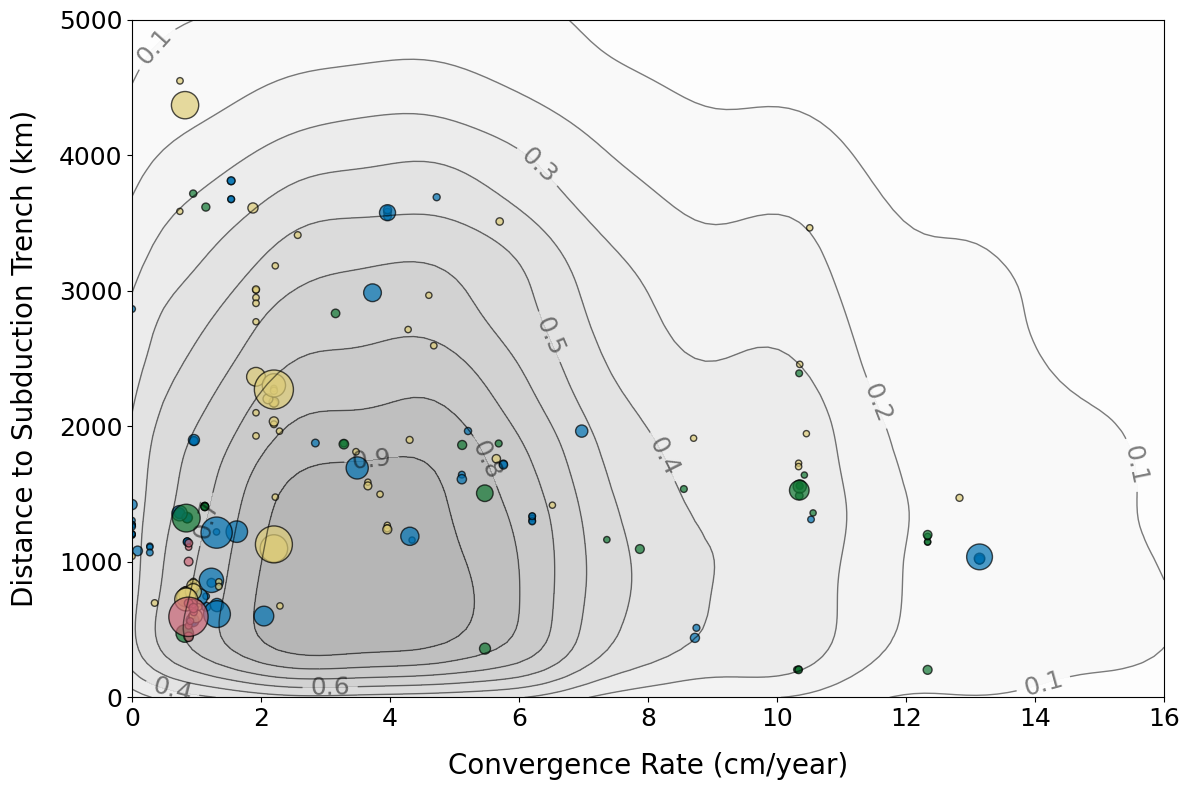

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Load your CSV file into a DataFrame
file_path = 'deposits_VS_random.csv'  # Update with your file path
df = pd.read_csv(file_path)

# Define columns for deposit and random data
x_deposit = 'D_sb_ve'
y_deposit = 'D_ds_tr'
x_random = 'R_sb_ve'
y_random = 'R_ds_tr'
weights_column = 'TM2'

# Select data without filtering NaN
deposit_data = df[[x_deposit, y_deposit, weights_column, 'Type']]
random_data = df[[x_random, y_random]]

# Remove negative values
deposit_data = deposit_data[(deposit_data[x_deposit] >= 0) & (deposit_data[y_deposit] >= 0)]
random_data = random_data[(random_data[x_random] >= 0) & (random_data[y_random] >= 0)]

# Extract data and weights
x_deposit_values = deposit_data[x_deposit]
y_deposit_values = deposit_data[y_deposit]
deposit_weights = deposit_data[weights_column]
deposit_types = deposit_data['Type']

x_random_values = random_data[x_random]
y_random_values = random_data[y_random]

# Define colors based on deposit type
type_colors = {
    'PbZn-CD': '#0072B2',  # Blue
    'PbZn-MVT': '#117733',  # Green
    'Cu-Sed': '#DDCC77',  # Yellow
    'IOCG': '#CC6677',  # Pink
    'Unknown': 'gray'  # For any NaN or unknown types
}

# Map TM2 to size using a continuous scale
min_size, max_size = 20, 800  # Minimum and maximum sizes for scaling
scaled_sizes = (deposit_weights - deposit_weights.min()) / (deposit_weights.max() - deposit_weights.min())
scaled_sizes = scaled_sizes * (max_size - min_size) + min_size

# Compute density contours for random points
xmin, xmax = 0, 16
ymin, ymax = 0, 5000
xx, yy = np.meshgrid(np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100))

# Compute KDE for random points
values = np.vstack([x_random_values, y_random_values])
kde = gaussian_kde(values)
density = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

# Normalize density values to range between 0 and 1
density_normalized = density / density.max()

# Create plot
plt.figure(figsize=(12, 8))

# Plot filled gray contour for random points
contour = plt.contourf(xx, yy, density_normalized, levels=10, cmap='Greys', alpha=0.3)
cset = plt.contour(xx, yy, density_normalized, levels=10, colors='black', linewidths=1, alpha=0.5)

# Ensure contour labels are readable
plt.clabel(cset, inline=True, fontsize=18, fmt="%.1f")  # **Larger contour labels**

# Scatter plot for deposits with continuous scaling, colored by type
for deposit_type in deposit_types.unique():
    if pd.isna(deposit_type) or deposit_type == 'Unknown':
        continue
    type_data = deposit_data[deposit_data['Type'] == deposit_type]
    plt.scatter(type_data[x_deposit], type_data[y_deposit],
                s=scaled_sizes[type_data.index],
                color=type_colors.get(deposit_type, 'gray'),
                edgecolor='black',
                alpha=0.7, label=f'{deposit_type}', marker='o')

# Add placeholders for Deposit Types and Deposit Size
legend_elements = []
for deposit_type, color in type_colors.items():
    if deposit_type != 'Unknown':  # Keep all deposit types
        legend_elements.append(plt.Line2D([0], [0], marker='o', color=color, label=deposit_type, markersize=12, 
                                          markeredgecolor='black', linestyle='None'))

# Add Deposit Size section
legend_elements.append(plt.Line2D([0], [0], label='Deposit Size', color='none', markersize=20))
legend_elements.append(plt.scatter([], [], s=min_size, color='white', alpha=1, edgecolor='black', label='0.1 Mt', marker='o'))
legend_elements.append(plt.scatter([], [], s=max_size, color='white', alpha=1, edgecolor='black', label='84 Mt', marker='o'))

# Add legend entry for random point density contours (Split into two rows)
legend_elements.append(plt.Line2D([0], [0], color='black', linewidth=4, 
                                  label='Random Points\nDensity Contours'))  # **Two-line label**

# Set axis limits
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])

# Labels and legend
plt.xlabel('Convergence Rate (cm/year)', fontsize=20, labelpad=15)
plt.ylabel('Distance to Subduction Trench (km)', fontsize=20, labelpad=15)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Adjust the legend with **tighter line spacing**
#plt.legend(handles=legend_elements, loc='upper right', frameon=True, labelspacing=0.5,  # **Tighter line spacing**
           #fontsize=20, title_fontsize=20, title="")  # Empty title removes "Deposit Types"

#plt.title('Density Contours of Random Points with Deposits', fontsize=22)
plt.tight_layout()
plt.show()


In [ ]:
# subduction length

In [53]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np
# import seaborn as sns
# from scipy.stats import gaussian_kde

# # Load your CSV file into a DataFrame
# file_path = 'deposits_VS_random.csv'  # Update with your file path
# df = pd.read_csv(file_path)

# # Define columns for deposit and random data
# x_deposit = 'D_cr_ve_m'
# y_deposit = 'D_sub_len_m'
# x_random = 'R_cr_ve_m'
# y_random = 'R_sub_len_m'
# weights_column = 'TM2'

# # Select data without filtering NaN
# deposit_data = df[[x_deposit, y_deposit, weights_column, 'Type']]
# random_data = df[[x_random, y_random]]

# # Remove negative values
# deposit_data = deposit_data[(deposit_data[x_deposit] >= 0) & (deposit_data[y_deposit] >= 0)]
# random_data = random_data[(random_data[x_random] >= 0) & (random_data[y_random] >= 0)]

# # Extract data and weights
# x_deposit_values = deposit_data[x_deposit]
# y_deposit_values = deposit_data[y_deposit]
# deposit_weights = deposit_data[weights_column]
# deposit_types = deposit_data['Type']

# x_random_values = random_data[x_random]
# y_random_values = random_data[y_random]

# # Define colors based on deposit type
# type_colors = {
#     'PbZn-CD': '#0072B2',  # Blue
#     'PbZn-MVT': '#117733',  # Green
#     'Cu-Sed': '#DDCC77',  # Yellow
#     'IOCG': '#CC6677',  # Pink
#     'Unknown': 'gray'  # For any NaN or unknown types
# }

# # Map TM2 to size using a continuous scale
# min_size, max_size = 20, 800  # Minimum and maximum sizes for scaling
# scaled_sizes = (deposit_weights - deposit_weights.min()) / (deposit_weights.max() - deposit_weights.min())
# scaled_sizes = scaled_sizes * (max_size - min_size) + min_size

# # Compute density contours for random points
# xmin, xmax = 0, 18
# ymin, ymax = 0, 15000
# xx, yy = np.meshgrid(np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100))

# # Compute KDE for random points
# values = np.vstack([x_random_values, y_random_values])
# kde = gaussian_kde(values)
# density = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

# # Normalize density values to range between 0 and 1
# density_normalized = density / density.max()

# # Create plot
# plt.figure(figsize=(12, 8))

# # Plot filled gray contour for random points
# contour = plt.contourf(xx, yy, density_normalized, levels=10, cmap='Greys', alpha=0.3)
# cset = plt.contour(xx, yy, density_normalized, levels=10, colors='black', linewidths=1, alpha=0.5)

# # Ensure contour labels are readable
# plt.clabel(cset, inline=True, fontsize=18, fmt="%.1f")  # **Larger contour labels**

# # Scatter plot for deposits with continuous scaling, colored by type
# for deposit_type in deposit_types.unique():
#     if pd.isna(deposit_type) or deposit_type == 'Unknown':
#         continue
#     type_data = deposit_data[deposit_data['Type'] == deposit_type]
#     plt.scatter(type_data[x_deposit], type_data[y_deposit],
#                 s=scaled_sizes[type_data.index],
#                 color=type_colors.get(deposit_type, 'gray'),
#                 edgecolor='black',
#                 alpha=0.7, label=f'{deposit_type}', marker='o')

# # Add placeholders for Deposit Types and Deposit Size
# legend_elements = []
# for deposit_type, color in type_colors.items():
#     if deposit_type != 'Unknown':  # Keep all deposit types
#         legend_elements.append(plt.Line2D([0], [0], marker='o', color=color, label=deposit_type, markersize=12, 
#                                           markeredgecolor='black', linestyle='None'))

# # Add Deposit Size section
# legend_elements.append(plt.Line2D([0], [0], label='Deposit Size', color='none', markersize=20))
# legend_elements.append(plt.scatter([], [], s=min_size, color='white', alpha=1, edgecolor='black', label='0.1 Mt', marker='o'))
# legend_elements.append(plt.scatter([], [], s=max_size, color='white', alpha=1, edgecolor='black', label='84 Mt', marker='o'))

# # Add legend entry for random point density contours (Split into two rows)
# legend_elements.append(plt.Line2D([0], [0], color='black', linewidth=4, 
#                                   label='Random Points\nDensity Contours'))  # **Two-line label**

# # Set axis limits
# plt.xlim([xmin, xmax])
# plt.ylim([ymin, ymax])

# # Labels and legend
# plt.xlabel('Craton Velocity (cm/year)', fontsize=20, labelpad=15)
# plt.ylabel('Subduction Segment Length (km)', fontsize=20, labelpad=15)
# plt.xticks(fontsize=18)
# plt.yticks(fontsize=18)

# # Adjust the legend with **tighter line spacing**
# plt.legend(handles=legend_elements, loc='upper right', frameon=True, labelspacing=0.5,  # **Tighter line spacing**
#            fontsize=20, title_fontsize=20, title="")  # Empty title removes "Deposit Types"

# #plt.title('Density Contours of Random Points with Deposits', fontsize=22)
# plt.tight_layout()
# plt.show()


# box-violin

In [63]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np
# import matplotlib.colors as mcolors

# # Load your CSV file into a DataFrame
# file_path = 'deposits_VS_random.csv'  # Update with your file path
# df = pd.read_csv(file_path)
# df = df[(df['R_cr_ve'] >= 0) & (df['R_cr_ve'] <= 18)]
# df = df[(df['R_sb_ve'] >= 0) & (df['R_sb_ve'] <= 25)]
# df = df[(df['R_ds_tr'] >= 0) & (df['R_ds_tr'] <= 8500)]



# # Define columns for deposit and random data (REMOVED subduction length)
# features = [
#     ("D_cr_ve", "R_cr_ve", "Craton Velocity (cm/year)"),
#     ("D_sb_ve", "R_sb_ve", "Convergence Rate (cm/year)"),
#     ("D_ds_tr", "R_ds_tr", "Distance to Subduction Trench (km)")
# ]
# weights_column = 'TM2'

# # Define deposit types and their colors
# deposit_types = ['PbZn-CD', 'PbZn-MVT', 'Cu-Sed', 'IOCG']
# type_colors = {
#     'PbZn-CD': '#0072B2',  # Blue
#     'PbZn-MVT': '#117733',  # Green
#     'Cu-Sed': '#DDCC77',  # Yellow
#     'IOCG': '#CC6677',  # Pink
#     'Combined': 'darkorange',  # Orange for all deposits
#     'Random': 'gray'  # Gray for random points
# }

# # Drop NaN values for deposits and random points
# deposit_data = df[[col[0] for col in features] + [weights_column, 'Type']].dropna()
# random_data = df[[col[1] for col in features]].dropna()

# # Remove negative values
# for col in [col[0] for col in features]:
#     deposit_data = deposit_data[deposit_data[col] >= 0]
# for col in [col[1] for col in features]:
#     random_data = random_data[random_data[col] >= 0]

# # Combine all deposit types into a single category
# deposit_data_combined = deposit_data.copy()
# deposit_data_combined['Type'] = 'Combined'

# # Create subplots for all features
# num_features = len(features)
# fig, axes = plt.subplots(num_features, 1, figsize=(12, 6 * num_features))
# fig.set_facecolor('white')  # Set overall background to white

# # Loop through each feature and plot
# for i, (deposit_col, random_col, ylabel) in enumerate(features):
#     ax = axes[i] if num_features > 1 else axes
#     ax.set_facecolor('white')  # Set individual plot background to white
#     position_offset = 0
#     position_step = 0.3
#     positions = []
#     labels = []

#     for deposit_type in deposit_types:
#         deposit_type_data = deposit_data[deposit_data['Type'] == deposit_type]
#         plot_data_deposit = deposit_type_data[deposit_col].dropna()
#         positions.append(position_offset)
#         labels.append(deposit_type)
        
#         vplot_parts = ax.violinplot([plot_data_deposit], positions=[position_offset], widths=0.2, showmedians=True)
#         bp = ax.boxplot([plot_data_deposit], positions=[position_offset], widths=0.05, patch_artist=False,
#                         whis=(5, 95), medianprops=dict(color='black', linewidth=3), showfliers=False)
        
#         for body in vplot_parts['bodies']:
#             body.set_facecolor(type_colors.get(deposit_type, 'lightblue'))
#             body.set_edgecolor('black')
#             body.set_alpha(0.6)

#         position_offset += position_step

#     # Combined deposits
#     plot_data_deposit_combined = deposit_data_combined[deposit_col].dropna()
#     positions.append(position_offset)
#     labels.append('All Deposits')
    
#     vplot_combined = ax.violinplot([plot_data_deposit_combined], positions=[position_offset], widths=0.2, showmedians=True)
#     bp_combined = ax.boxplot([plot_data_deposit_combined], positions=[position_offset], widths=0.05, patch_artist=False,
#                               whis=(5, 95), medianprops=dict(color='black', linewidth=3), showfliers=False)
    
#     for body in vplot_combined['bodies']:
#         body.set_facecolor(type_colors['Combined'])
#         body.set_edgecolor('black')
#         body.set_alpha(0.6)

#     position_offset += position_step

#     # Random points
#     plot_data_random = random_data[random_col].dropna()
#     positions.append(position_offset)
#     labels.append('Random')
    
#     vplot_random = ax.violinplot([plot_data_random], positions=[position_offset], widths=0.2, showmedians=True)
#     bp_random = ax.boxplot([plot_data_random], positions=[position_offset], widths=0.05, patch_artist=False,
#                             whis=(5, 95), medianprops=dict(color='black', linewidth=3), showfliers=False)
    
#     for body in vplot_random['bodies']:
#         body.set_facecolor(type_colors['Random'])
#         body.set_edgecolor('black')
#         body.set_alpha(0.6)

#     # Format axes
#     ax.set_xticks(positions)
#     ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=20)
#     ax.set_xlim(-0.1, position_offset + 0.1)
#     ax.set_ylabel(ylabel, fontsize=20)
#     ax.tick_params(axis='both', labelsize=20)

# plt.tight_layout()
# plt.show()


C:\Users\Hojat\AppData\Local\Temp\ipykernel_3536\2768696915.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


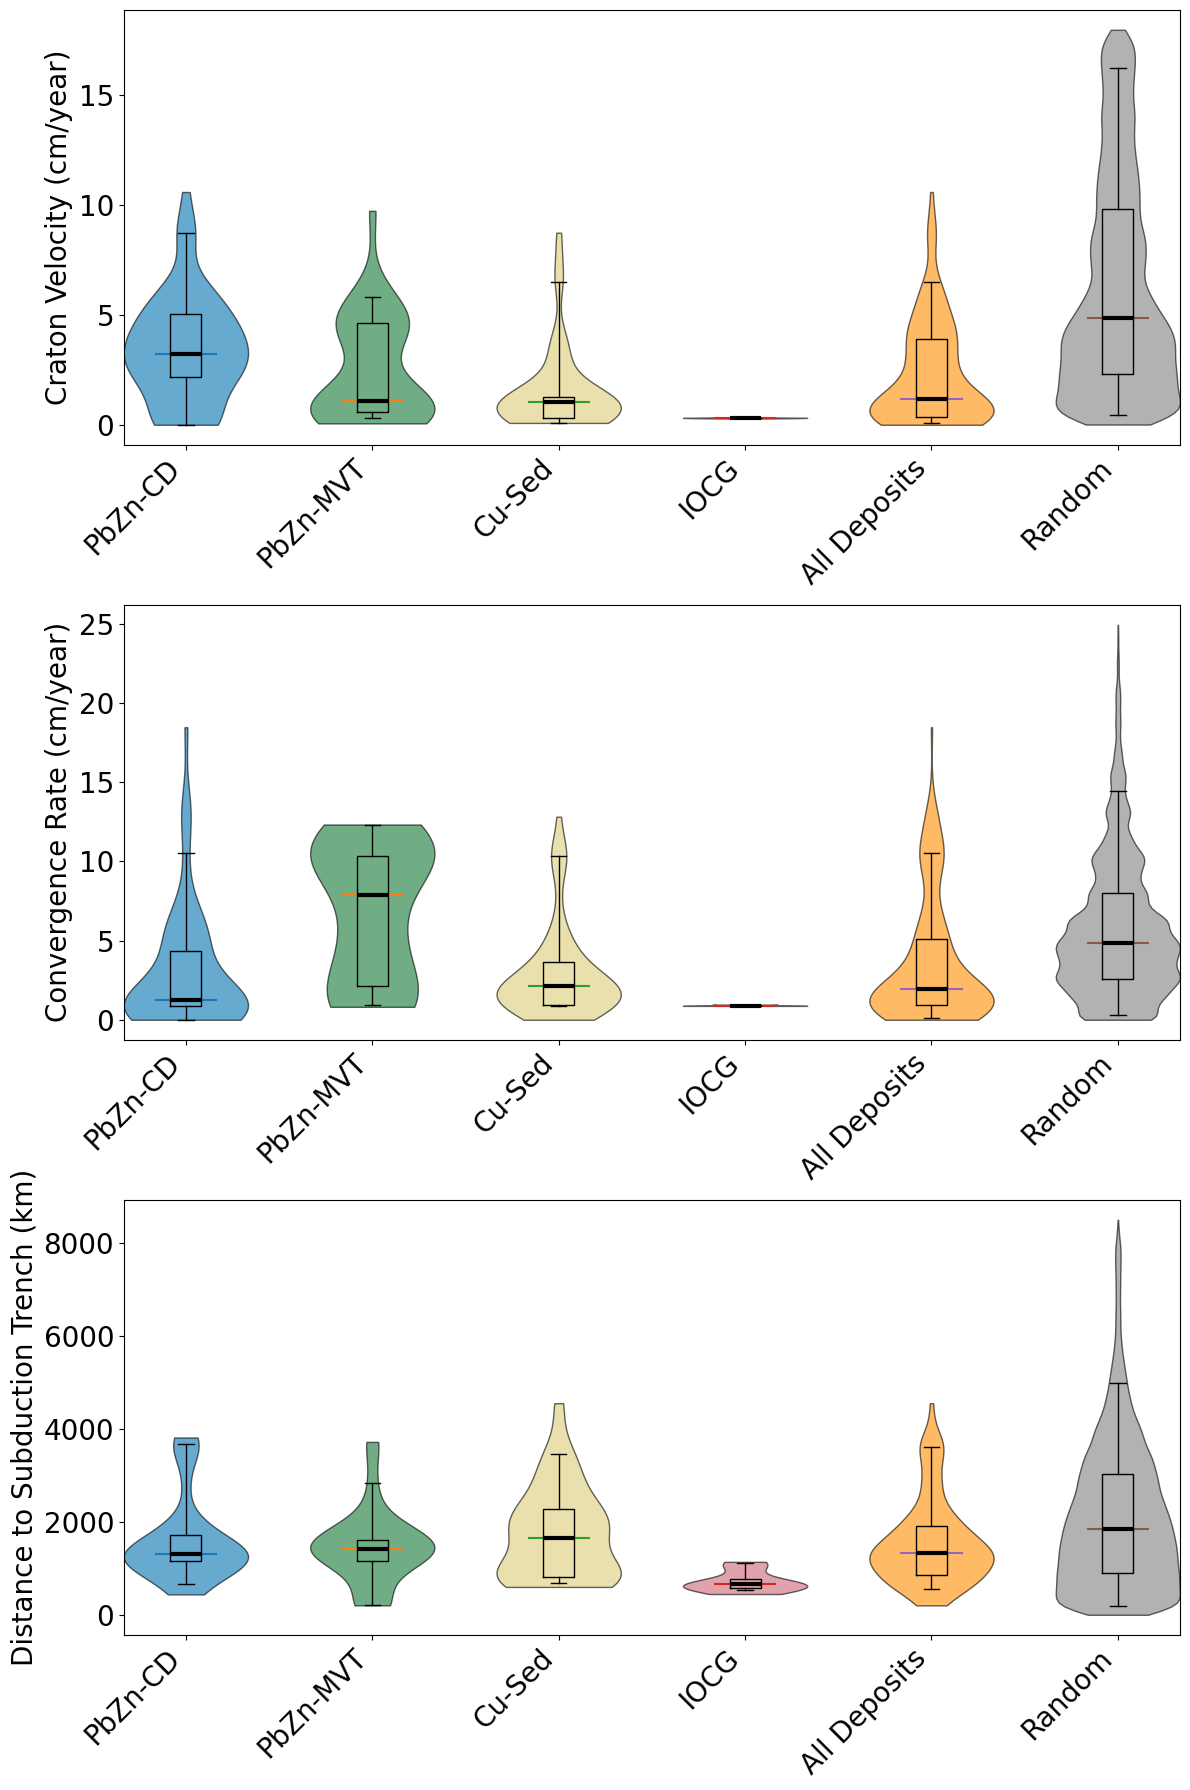

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Load your CSV file into a DataFrame
file_path = 'deposits_VS_random.csv'  # Update with your file path
df = pd.read_csv(file_path)
df = df[(df['R_cr_ve'] >= 0) & (df['R_cr_ve'] <= 18)]
df = df[(df['R_sb_ve'] >= 0) & (df['R_sb_ve'] <= 25)]
df = df[(df['R_ds_tr'] >= 0) & (df['R_ds_tr'] <= 8500)]

# Define columns for deposit and random data (REMOVED subduction length)
features = [
    ("D_cr_ve", "R_cr_ve", "Craton Velocity (cm/year)"),
    ("D_sb_ve", "R_sb_ve", "Convergence Rate (cm/year)"),
    ("D_ds_tr", "R_ds_tr", "Distance to Subduction Trench (km)")
]
weights_column = 'TM2'

# Define deposit types and their colors
deposit_types = ['PbZn-CD', 'PbZn-MVT', 'Cu-Sed', 'IOCG']
type_colors = {
    'PbZn-CD': '#0072B2',  # Blue
    'PbZn-MVT': '#117733',  # Green
    'Cu-Sed': '#DDCC77',  # Yellow
    'IOCG': '#CC6677',  # Pink
    'Combined': 'darkorange',  # Orange for all deposits
    'Random': 'gray'  # Gray for random points
}

# Drop NaN values for deposits and random points
deposit_data = df[[col[0] for col in features] + [weights_column, 'Type']].dropna()
random_data = df[[col[1] for col in features]].dropna()

# Remove negative values
for col in [col[0] for col in features]:
    deposit_data = deposit_data[deposit_data[col] >= 0]
for col in [col[1] for col in features]:
    random_data = random_data[random_data[col] >= 0]

# Combine all deposit types into a single category
deposit_data_combined = deposit_data.copy()
deposit_data_combined['Type'] = 'Combined'

# Create subplots for all features
num_features = len(features)
fig, axes = plt.subplots(num_features, 1, figsize=(12, 6 * num_features))
fig.set_facecolor('white')  # Set overall background to white

# Loop through each feature and plot
for i, (deposit_col, random_col, ylabel) in enumerate(features):
    ax = axes[i] if num_features > 1 else axes
    ax.set_facecolor('white')  # Set individual plot background to white
    position_offset = 0
    position_step = 0.3
    positions = []
    labels = []

    for deposit_type in deposit_types:
        deposit_type_data = deposit_data[deposit_data['Type'] == deposit_type]
        plot_data_deposit = deposit_type_data[deposit_col].dropna()
        positions.append(position_offset)
        labels.append(deposit_type)
        
        vplot_parts = ax.violinplot([plot_data_deposit], positions=[position_offset], widths=0.2, showmedians=True)
        
        # Remove violin whiskers
        for partname in ('cbars', 'cmins', 'cmaxes'):
            vplot_parts[partname].set_visible(False)

        bp = ax.boxplot([plot_data_deposit], positions=[position_offset], widths=0.05, patch_artist=False,
                        whis=(5, 95), medianprops=dict(color='black', linewidth=3), showfliers=False)
        
        for body in vplot_parts['bodies']:
            body.set_facecolor(type_colors.get(deposit_type, 'lightblue'))
            body.set_edgecolor('black')
            body.set_alpha(0.6)

        position_offset += position_step

    # Combined deposits
    plot_data_deposit_combined = deposit_data_combined[deposit_col].dropna()
    positions.append(position_offset)
    labels.append('All Deposits')
    
    vplot_combined = ax.violinplot([plot_data_deposit_combined], positions=[position_offset], widths=0.2, showmedians=True)
    
    for partname in ('cbars', 'cmins', 'cmaxes'):
        vplot_combined[partname].set_visible(False)

    bp_combined = ax.boxplot([plot_data_deposit_combined], positions=[position_offset], widths=0.05, patch_artist=False,
                              whis=(5, 95), medianprops=dict(color='black', linewidth=3), showfliers=False)
    
    for body in vplot_combined['bodies']:
        body.set_facecolor(type_colors['Combined'])
        body.set_edgecolor('black')
        body.set_alpha(0.6)

    position_offset += position_step

    # Random points
    plot_data_random = random_data[random_col].dropna()
    positions.append(position_offset)
    labels.append('Random')
    
    vplot_random = ax.violinplot([plot_data_random], positions=[position_offset], widths=0.2, showmedians=True)
    
    for partname in ('cbars', 'cmins', 'cmaxes'):
        vplot_random[partname].set_visible(False)

    bp_random = ax.boxplot([plot_data_random], positions=[position_offset], widths=0.05, patch_artist=False,
                            whis=(5, 95), medianprops=dict(color='black', linewidth=3), showfliers=False)
    
    for body in vplot_random['bodies']:
        body.set_facecolor(type_colors['Random'])
        body.set_edgecolor('black')
        body.set_alpha(0.6)

    # Format axes
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=20)
    ax.set_xlim(-0.1, position_offset + 0.1)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.tick_params(axis='both', labelsize=20)

plt.tight_layout()
plt.show()


C:\Users\hshi9735\AppData\Local\Temp\ipykernel_20508\3407707328.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


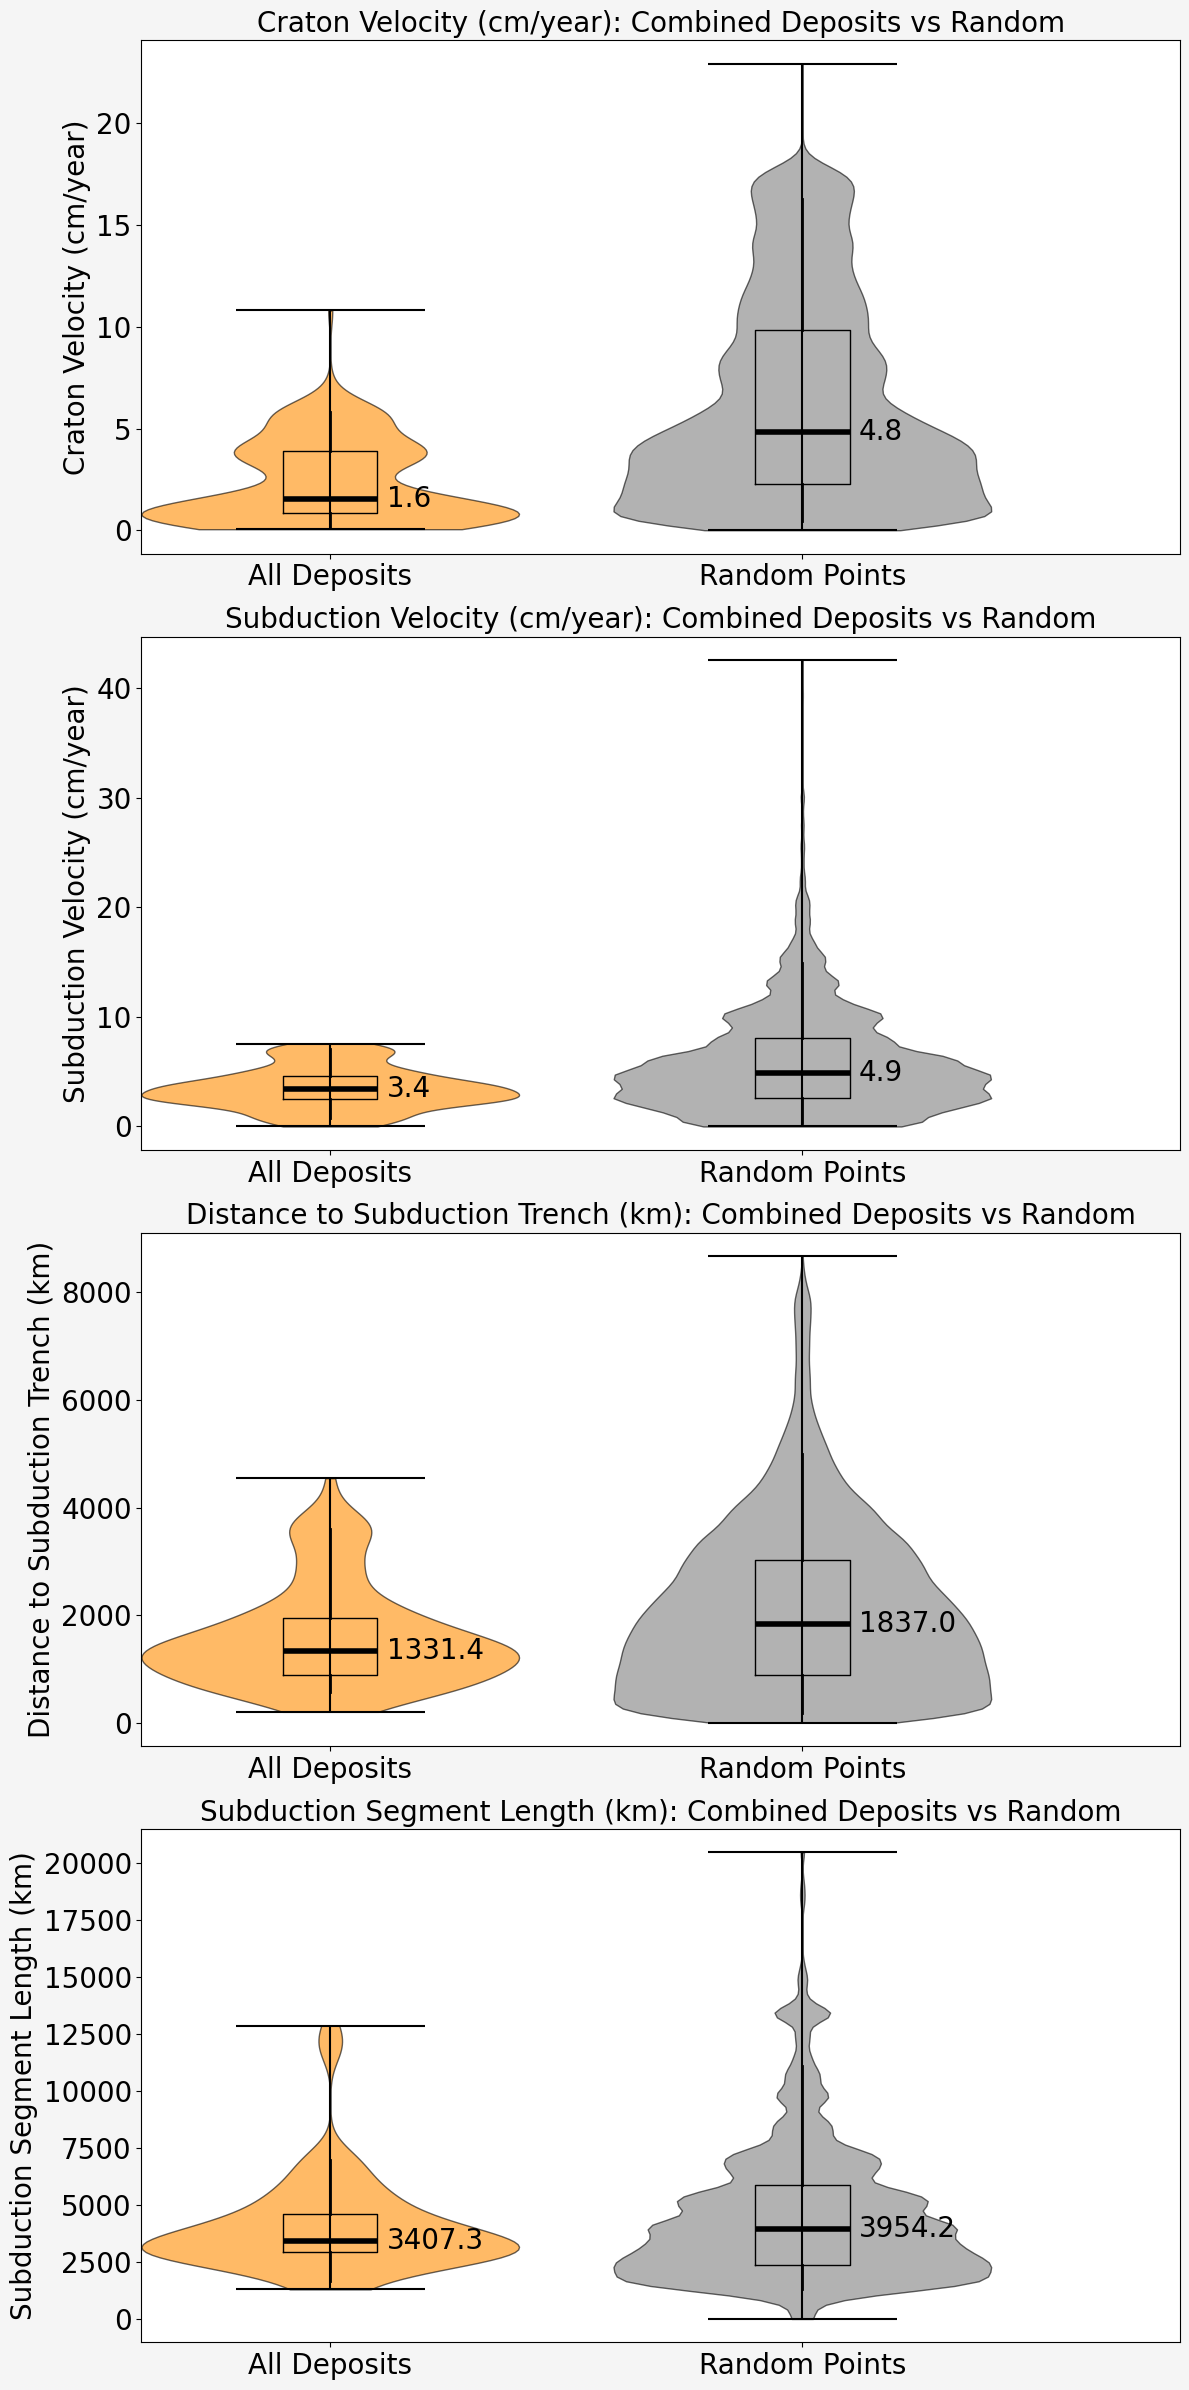

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Load your CSV file into a DataFrame
file_path = './deposits_VS_random.csv'  # Path to your uploaded file
df = pd.read_csv(file_path)

# Define columns for deposit and random data
features = [
    ("D_cr_ve_m", "R_cr_ve_m", "Craton Velocity (cm/year)"),
    ("D_sb_ve_m", "R_sb_ve_m", "Subduction Velocity (cm/year)"),
    ("D_ds_tr", "R_ds_tr", "Distance to Subduction Trench (km)"),
    ("D_sub_len_m", "R_sub_len_m", "Subduction Segment Length (km)"),
]
weights_column = 'TM2'

# Define colors
deposit_color = mcolors.CSS4_COLORS['darkorange']  # Colorblind-safe red-orange
random_color = 'gray'
position_offset_random = 0.25  # Adjust position to avoid overlap

# Drop NaN values for deposits and random points
deposit_data = df[[col[0] for col in features] + [weights_column, 'Type']].dropna()
random_data = df[[col[1] for col in features]].dropna()

# Remove negative values
for col in [col[0] for col in features]:
    deposit_data = deposit_data[deposit_data[col] >= 0]

for col in [col[1] for col in features]:
    random_data = random_data[random_data[col] >= 0]

# Combine all deposit types into a single category
deposit_data_combined = deposit_data.copy()
deposit_data_combined['Type'] = 'Combined'

# Create subplots for all features with adjusted positions and median labels
num_features = len(features)
fig, axes = plt.subplots(num_features, 1, figsize=(12, 6 * num_features))
fig.set_facecolor('whitesmoke')

# Loop through each feature and plot
for i, (deposit_col, random_col, ylabel) in enumerate(features):
    ax = axes[i] if num_features > 1 else axes

    # Extract data for combined deposits and random points
    plot_data_deposit = deposit_data_combined[deposit_col]
    plot_data_random = random_data[random_col]

    # Positioning for violin plots
    positions = [0, position_offset_random]

    # Plot combined deposit data and random data
    vplot_parts = ax.violinplot([plot_data_deposit, plot_data_random], positions=positions, widths=0.2)
    bp = ax.boxplot(
        [plot_data_deposit, plot_data_random], positions=positions, widths=0.05, patch_artist=False, whis=(5, 95),
        flierprops=dict(marker='None'),  # Remove outliers
        medianprops=dict(color='black', linewidth=4),  # Doubled line width
        whiskerprops=dict(color='black', linestyle='-', linewidth=2),  # Doubled line width
        capprops=dict(visible=False)
    )

    # Style violin plots
    for j, body in enumerate(vplot_parts['bodies']):
        if j == 0:  # Combined deposit data
            body.set_facecolor(deposit_color)  # Red-orange for combined deposits
        else:  # Random data
            body.set_facecolor(random_color)  # Gray for random points
        body.set_edgecolor('black')
        body.set_alpha(0.6)

    vplot_parts['cbars'].set_edgecolor('black')
    vplot_parts['cmins'].set_edgecolor('black')
    vplot_parts['cmaxes'].set_edgecolor('black')

    # Calculate and label median values
    deposit_median = plot_data_deposit.median()
    random_median = plot_data_random.median()
    ax.text(positions[0] + 0.03, deposit_median, f'{deposit_median:.1f}', color='black', ha='left', va='center', fontsize=20)
    ax.text(positions[1] + 0.03, random_median, f'{random_median:.1f}', color='black', ha='left', va='center', fontsize=20)

    # Format axes
    ax.set_xticks(positions)
    ax.set_xticklabels(['All Deposits', 'Random Points'], rotation=0, fontsize=20)
    ax.set_xlim(-0.1, position_offset_random + 0.2)
    ax.set_ylabel(ylabel, fontsize=20)  # Double font size for y-axis label
    ax.set_title(f'{ylabel}: Combined Deposits vs Random', fontsize=20)

    # Ensure all tick labels are doubled
    ax.tick_params(axis='both', labelsize=20)

plt.tight_layout()
plt.show()


C:\Users\Hojat\AppData\Local\Temp\ipykernel_26920\223524741.py:7: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


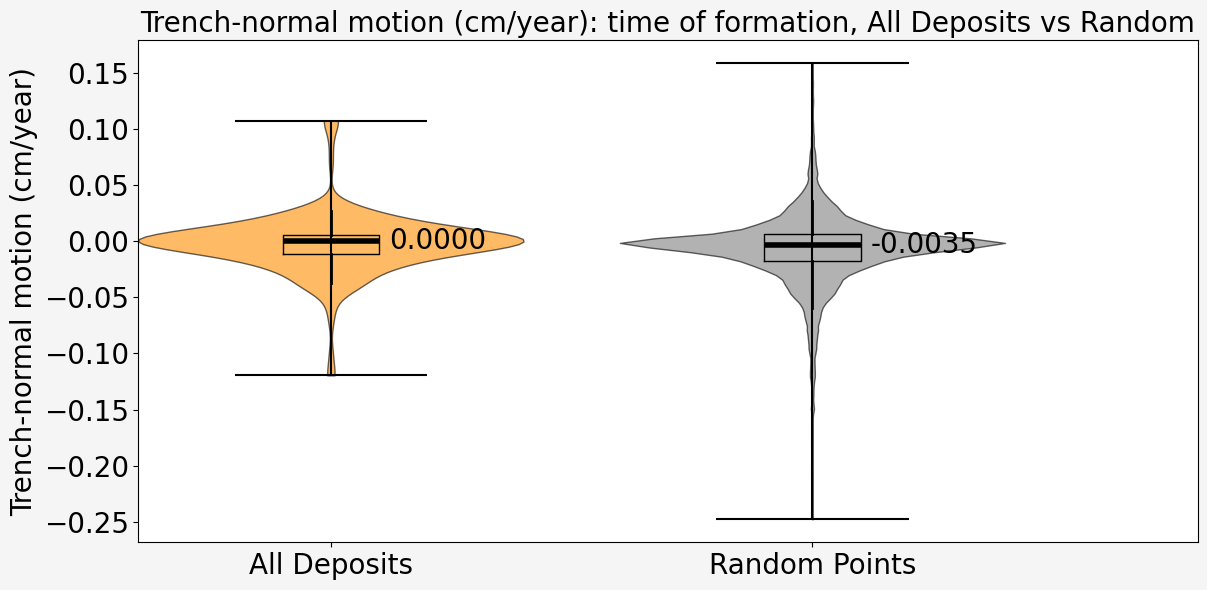

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Load your CSV file into a DataFrame
file_path = './deposits_VS_random.csv'
df = pd.read_csv(file_path)

# Define columns for deposit and random data
features = [
    ("D_tr_adv", "R_tr_adv", "Trench-normal motion (cm/year)")
]

weights_column = 'TM2'

# Define colors
deposit_color = mcolors.CSS4_COLORS['darkorange']
random_color = 'gray'
position_offset_random = 0.25

# Drop NaN values only (keep negatives!)
deposit_data = df[[col[0] for col in features] + [weights_column, 'Type']].dropna()
random_data = df[[col[1] for col in features]].dropna()

# Combine all deposit types into a single category
deposit_data_combined = deposit_data.copy()
deposit_data_combined['Type'] = 'Combined'

# Create subplots
num_features = len(features)
fig, axes = plt.subplots(num_features, 1, figsize=(12, 6 * num_features))
fig.set_facecolor('whitesmoke')

# Loop through each feature and plot
for i, (deposit_col, random_col, ylabel) in enumerate(features):
    ax = axes[i] if num_features > 1 else axes

    # Extract data
    plot_data_deposit = deposit_data_combined[deposit_col]
    plot_data_random = random_data[random_col]

    positions = [0, position_offset_random]

    # Violin and box plots
    vplot_parts = ax.violinplot([plot_data_deposit, plot_data_random], positions=positions, widths=0.2)
    bp = ax.boxplot(
        [plot_data_deposit, plot_data_random], positions=positions, widths=0.05, patch_artist=False, whis=(5, 95),
        flierprops=dict(marker='None'),
        medianprops=dict(color='black', linewidth=4),
        whiskerprops=dict(color='black', linestyle='-', linewidth=2),
        capprops=dict(visible=False)
    )

    # Style violins
    for j, body in enumerate(vplot_parts['bodies']):
        color = deposit_color if j == 0 else random_color
        body.set_facecolor(color)
        body.set_edgecolor('black')
        body.set_alpha(0.6)

    vplot_parts['cbars'].set_edgecolor('black')
    vplot_parts['cmins'].set_edgecolor('black')
    vplot_parts['cmaxes'].set_edgecolor('black')

    # Annotate medians
    deposit_median = plot_data_deposit.median()
    random_median = plot_data_random.median()
    ax.text(positions[0] + 0.03, deposit_median, f'{deposit_median:.4f}', color='black', ha='left', va='center', fontsize=20)
    ax.text(positions[1] + 0.03, random_median, f'{random_median:.4f}', color='black', ha='left', va='center', fontsize=20)

    # Axis formatting
    ax.set_xticks(positions)
    ax.set_xticklabels(['All Deposits', 'Random Points'], rotation=0, fontsize=20)
    ax.set_xlim(-0.1, position_offset_random + 0.2)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.set_title(f'{ylabel}: time of formation, All Deposits vs Random', fontsize=20)
    ax.tick_params(axis='both', labelsize=20)

plt.tight_layout()
plt.show()


C:\Users\Hojat\AppData\Local\Temp\ipykernel_26920\2734787758.py:7: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


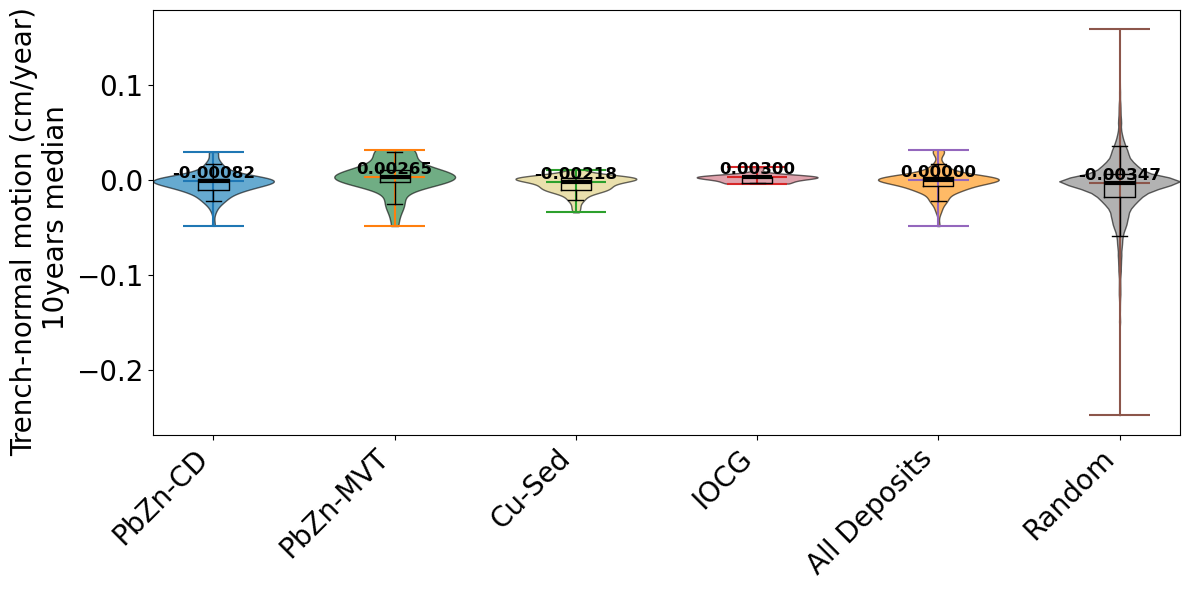

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your CSV file into a DataFrame
file_path = 'deposits_VS_random.csv'  # Update with your file path
df = pd.read_csv(file_path)

# Define columns for deposit and random data
features = [
    ("D_tr_adv_m", "R_tr_adv_m", "Trench-normal motion (cm/year) .\n 10years median")
]

weights_column = 'TM2'

# Define deposit types and their colors
deposit_types = ['PbZn-CD', 'PbZn-MVT', 'Cu-Sed', 'IOCG']
type_colors = {
    'PbZn-CD': '#0072B2',  # Blue
    'PbZn-MVT': '#117733',  # Green
    'Cu-Sed': '#DDCC77',  # Yellow
    'IOCG': '#CC6677',  # Pink
    'Combined': 'darkorange',  # Orange for all deposits
    'Random': 'gray'  # Gray for random points
}

# Drop NaN values
deposit_data = df[[col[0] for col in features] + [weights_column, 'Type']].dropna()
random_data = df[[col[1] for col in features]].dropna()

# Combine all deposit types into a single category
deposit_data_combined = deposit_data.copy()
deposit_data_combined['Type'] = 'Combined'

# Create subplots
num_features = len(features)
fig, axes = plt.subplots(num_features, 1, figsize=(12, 6 * num_features))
fig.set_facecolor('white')

for i, (deposit_col, random_col, ylabel) in enumerate(features):
    ax = axes[i] if num_features > 1 else axes
    ax.set_facecolor('white')
    position_offset = 0
    position_step = 0.3
    positions = []
    labels = []

    # Plot each deposit type
    for deposit_type in deposit_types:
        deposit_type_data = deposit_data[deposit_data['Type'] == deposit_type]
        plot_data_deposit = deposit_type_data[deposit_col].dropna()
        positions.append(position_offset)
        labels.append(deposit_type)
        
        vplot_parts = ax.violinplot([plot_data_deposit], positions=[position_offset], widths=0.2, showmedians=True)
        bp = ax.boxplot([plot_data_deposit], positions=[position_offset], widths=0.05, patch_artist=False,
                        whis=(5, 95), medianprops=dict(color='black', linewidth=3), showfliers=False)

        for body in vplot_parts['bodies']:
            body.set_facecolor(type_colors.get(deposit_type, 'lightblue'))
            body.set_edgecolor('black')
            body.set_alpha(0.6)

        # Add median label
        median_val = np.median(plot_data_deposit)
        ax.text(position_offset, median_val, f'{median_val:.5f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

        position_offset += position_step

    # Combined deposits
    plot_data_combined = deposit_data_combined[deposit_col].dropna()
    positions.append(position_offset)
    labels.append('All Deposits')

    vplot_combined = ax.violinplot([plot_data_combined], positions=[position_offset], widths=0.2, showmedians=True)
    bp_combined = ax.boxplot([plot_data_combined], positions=[position_offset], widths=0.05, patch_artist=False,
                              whis=(5, 95), medianprops=dict(color='black', linewidth=3), showfliers=False)

    for body in vplot_combined['bodies']:
        body.set_facecolor(type_colors['Combined'])
        body.set_edgecolor('black')
        body.set_alpha(0.6)

    median_val = np.median(plot_data_combined)
    ax.text(position_offset, median_val, f'{median_val:.5f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    position_offset += position_step

    # Random data
    plot_data_random = random_data[random_col].dropna()
    positions.append(position_offset)
    labels.append('Random')

    vplot_random = ax.violinplot([plot_data_random], positions=[position_offset], widths=0.2, showmedians=True)
    bp_random = ax.boxplot([plot_data_random], positions=[position_offset], widths=0.05, patch_artist=False,
                            whis=(5, 95), medianprops=dict(color='black', linewidth=3), showfliers=False)

    for body in vplot_random['bodies']:
        body.set_facecolor(type_colors['Random'])
        body.set_edgecolor('black')
        body.set_alpha(0.6)

    median_val = np.median(plot_data_random)
    ax.text(position_offset, median_val, f'{median_val:.5f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Final axis formatting
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=20)
    ax.set_xlim(-0.1, position_offset + 0.1)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.tick_params(axis='both', labelsize=20)

plt.tight_layout()
plt.show()


C:\Users\Hojat\AppData\Local\Temp\ipykernel_26920\1603868126.py:7: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


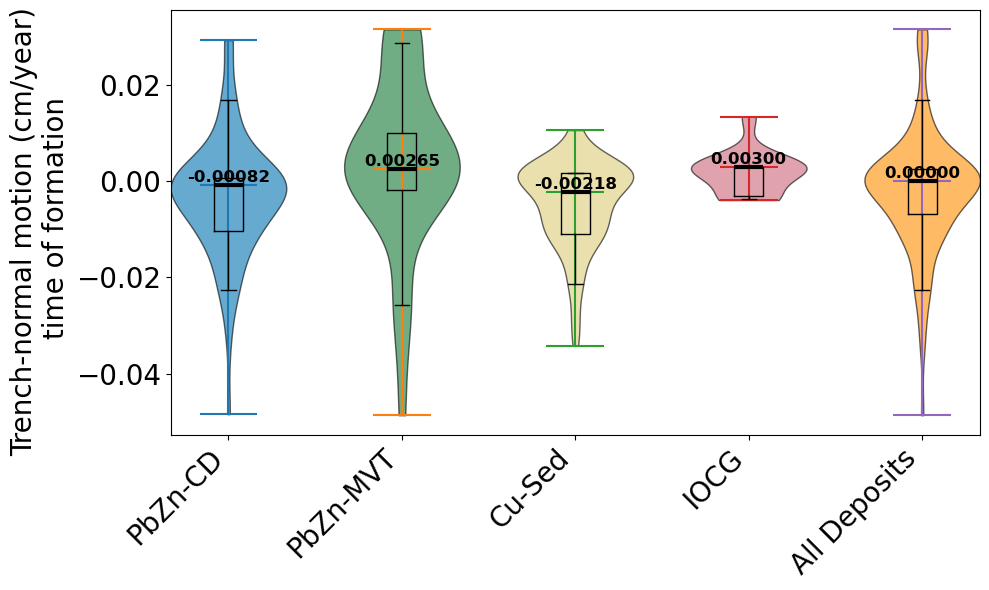

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your CSV file into a DataFrame
file_path = 'deposits_VS_random.csv'  # Update with your file path
df = pd.read_csv(file_path)

# Define columns for deposit data only
features = [
    ("D_tr_adv_m", "Trench-normal motion (cm/year) .\n time of formation")
]

weights_column = 'TM2'

# Define deposit types and their colors
deposit_types = ['PbZn-CD', 'PbZn-MVT', 'Cu-Sed', 'IOCG']
type_colors = {
    'PbZn-CD': '#0072B2',
    'PbZn-MVT': '#117733',
    'Cu-Sed': '#DDCC77',
    'IOCG': '#CC6677',
    'Combined': 'darkorange',
}

# Drop NaN values
deposit_data = df[[features[0][0], weights_column, 'Type']].dropna()

# Combine all deposit types into a single category
deposit_data_combined = deposit_data.copy()
deposit_data_combined['Type'] = 'Combined'

# Create subplots
num_features = len(features)
fig, axes = plt.subplots(num_features, 1, figsize=(10, 6 * num_features))
fig.set_facecolor('white')

for i, (deposit_col, ylabel) in enumerate(features):
    ax = axes[i] if num_features > 1 else axes
    ax.set_facecolor('white')
    position_offset = 0
    position_step = 0.3
    positions = []
    labels = []

    # Plot each deposit type
    for deposit_type in deposit_types:
        deposit_type_data = deposit_data[deposit_data['Type'] == deposit_type]
        plot_data_deposit = deposit_type_data[deposit_col].dropna()
        positions.append(position_offset)
        labels.append(deposit_type)
        
        vplot_parts = ax.violinplot([plot_data_deposit], positions=[position_offset], widths=0.2, showmedians=True)
        bp = ax.boxplot([plot_data_deposit], positions=[position_offset], widths=0.05, patch_artist=False,
                        whis=(5, 95), medianprops=dict(color='black', linewidth=3), showfliers=False)

        for body in vplot_parts['bodies']:
            body.set_facecolor(type_colors.get(deposit_type, 'lightblue'))
            body.set_edgecolor('black')
            body.set_alpha(0.6)

        # Add median label
        median_val = np.median(plot_data_deposit)
        ax.text(position_offset, median_val, f'{median_val:.5f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

        position_offset += position_step

    # Combined deposits
    plot_data_combined = deposit_data_combined[deposit_col].dropna()
    positions.append(position_offset)
    labels.append('All Deposits')

    vplot_combined = ax.violinplot([plot_data_combined], positions=[position_offset], widths=0.2, showmedians=True)
    bp_combined = ax.boxplot([plot_data_combined], positions=[position_offset], widths=0.05, patch_artist=False,
                              whis=(5, 95), medianprops=dict(color='black', linewidth=3), showfliers=False)

    for body in vplot_combined['bodies']:
        body.set_facecolor(type_colors['Combined'])
        body.set_edgecolor('black')
        body.set_alpha(0.6)

    median_val = np.median(plot_data_combined)
    ax.text(position_offset, median_val, f'{median_val:.5f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Final axis formatting
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=20)
    ax.set_xlim(-0.1, position_offset + 0.1)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.tick_params(axis='both', labelsize=20)

plt.tight_layout()
plt.show()


In [ ]:
# Skewness Value	Interpretation
# > 0	Positive skew (right tail)
# < 0	Negative skew (left tail)
# = 0	Symmetric / normal-ish

In [49]:
import pandas as pd
from scipy.stats import skew

data = df['D_tr_adv_m'].dropna()

# Option 1: Using pandas
print("Skewness (pandas):", data.skew())

# Option 2: Using scipy
print("Skewness (scipy):", skew(data, bias=False))

Skewness (pandas): -0.25188112592951484
Skewness (scipy): -0.25188112592951495


In [ ]:
# If mean > median → right skew
# If mean < median → left skew

In [50]:
mean = data.mean()
median = data.median()
print("Mean:", mean, "Median:", median)

Mean: -0.0020427223253588517 Median: 0.0


C:\Users\Hojat\AppData\Local\Temp\ipykernel_26920\696098089.py:9: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


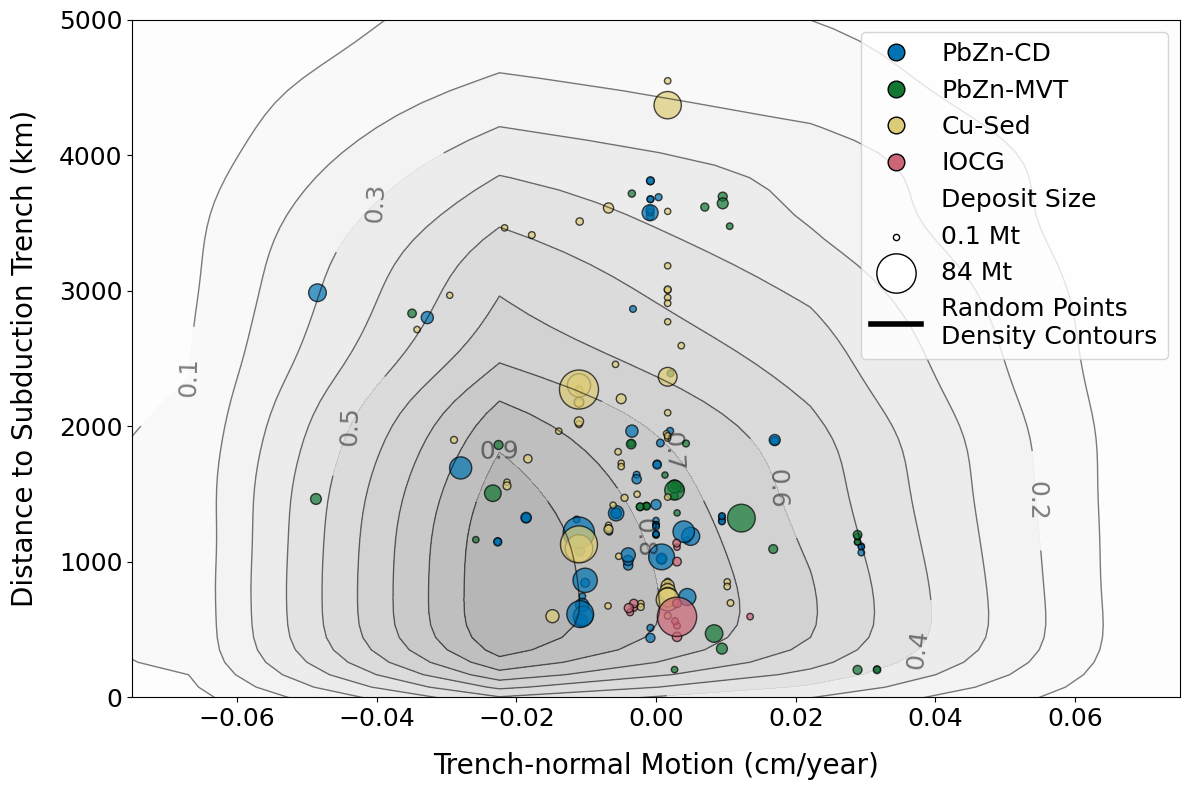

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import gaussian_kde

# Load your CSV file into a DataFrame
file_path = 'deposits_VS_random.csv'
df = pd.read_csv(file_path)

# Define columns
x_deposit = 'D_tr_adv_m'
y_deposit = 'D_ds_tr'
x_random = 'R_tr_adv_m'
y_random = 'R_ds_tr'
weights_column = 'TM2'

# Keep all values, including negatives
deposit_data = df[[x_deposit, y_deposit, weights_column, 'Type']].dropna()
random_data = df[[x_random, y_random]].dropna()

# Extract values
x_deposit_values = deposit_data[x_deposit]
y_deposit_values = deposit_data[y_deposit]
deposit_weights = deposit_data[weights_column]
deposit_types = deposit_data['Type']

x_random_values = random_data[x_random]
y_random_values = random_data[y_random]

# Define colors
type_colors = {
    'PbZn-CD': '#0072B2',
    'PbZn-MVT': '#117733',
    'Cu-Sed': '#DDCC77',
    'IOCG': '#CC6677',
    'Unknown': 'gray'
}

# Scale sizes based on TM2
min_size, max_size = 20, 800
scaled_sizes = (deposit_weights - deposit_weights.min()) / (deposit_weights.max() - deposit_weights.min())
scaled_sizes = scaled_sizes * (max_size - min_size) + min_size

# Compute density contours for random points
xx, yy = np.meshgrid(
    np.linspace(x_random_values.min() - 2, x_random_values.max() + 2, 100),
    np.linspace(y_random_values.min() - 200, y_random_values.max() + 200, 100)
)

values = np.vstack([x_random_values, y_random_values])
kde = gaussian_kde(values)
density = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
density_normalized = density / density.max()

# Create plot
plt.figure(figsize=(12, 8))

# Contour for random points
contour = plt.contourf(xx, yy, density_normalized, levels=10, cmap='Greys', alpha=0.3)
cset = plt.contour(xx, yy, density_normalized, levels=10, colors='black', linewidths=1, alpha=0.5)
plt.clabel(cset, inline=True, fontsize=18, fmt="%.1f")

# Scatter deposits by type
for deposit_type in deposit_types.unique():
    if pd.isna(deposit_type) or deposit_type == 'Unknown':
        continue
    type_data = deposit_data[deposit_data['Type'] == deposit_type]
    plt.scatter(type_data[x_deposit], type_data[y_deposit],
                s=scaled_sizes[type_data.index],
                color=type_colors.get(deposit_type, 'gray'),
                edgecolor='black',
                alpha=0.7, label=deposit_type)

# Legend elements
legend_elements = []
for deposit_type, color in type_colors.items():
    if deposit_type != 'Unknown':
        legend_elements.append(
            plt.Line2D([0], [0], marker='o', color=color, label=deposit_type,
                       markersize=12, markeredgecolor='black', linestyle='None')
        )

# Deposit size legend
legend_elements.append(plt.Line2D([0], [0], label='Deposit Size', color='none', markersize=20))
legend_elements.append(plt.scatter([], [], s=min_size, color='white', edgecolor='black', label='0.1 Mt'))
legend_elements.append(plt.scatter([], [], s=max_size, color='white', edgecolor='black', label='84 Mt'))

# Random point contour legend
legend_elements.append(plt.Line2D([0], [0], color='black', linewidth=4,
                                  label='Random Points\nDensity Contours'))

# Labels and formatting
plt.xlabel('Trench-normal Motion (cm/year)', fontsize=20, labelpad=15)
plt.ylabel('Distance to Subduction Trench (km)', fontsize=20, labelpad=15)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Axis limits: x from deposits, y from random
#plt.xlim(x_deposit_values.min() - 2, x_deposit_values.max() + 2)
plt.xlim(-0.075, 0.075)
#plt.ylim(y_random_values.min() - 200, y_random_values.max() + 200)
plt.ylim(0, 5000)

# Legend
plt.legend(handles=legend_elements, loc='upper right', frameon=True, labelspacing=0.5,
           fontsize=18, title_fontsize=20)

# Final layout
plt.tight_layout()
plt.show()


C:\Users\Hojat\AppData\Local\Temp\ipykernel_3536\4035582293.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


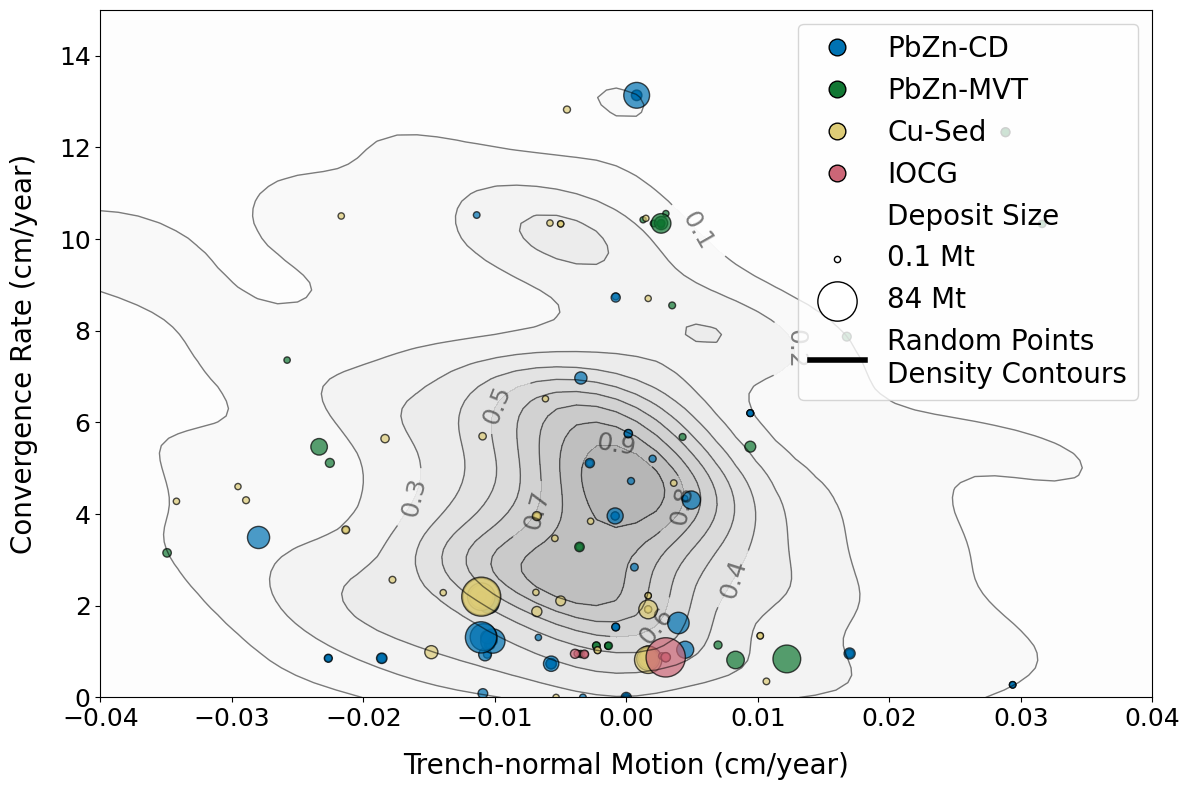

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Load your CSV file into a DataFrame
file_path = 'deposits_VS_random.csv'  # Update with your file path
df = pd.read_csv(file_path)

# Define columns
x_deposit = 'D_tr_adv_m'
y_deposit = 'D_sb_ve'
x_random = 'R_tr_adv_m'
y_random = 'R_sb_ve'
weights_column = 'TM2'

# Select data without filtering NaN
deposit_data = df[[x_deposit, y_deposit, weights_column, 'Type']]
random_data = df[[x_random, y_random]]

# Remove negative values
# Keep negative x values; only filter out invalid or negative y-values if needed
deposit_data = deposit_data[deposit_data[y_deposit] >= 0]
random_data = random_data[random_data[y_random] >= 0]

# Extract data and weights
x_deposit_values = deposit_data[x_deposit]
y_deposit_values = deposit_data[y_deposit]
deposit_weights = deposit_data[weights_column]
deposit_types = deposit_data['Type']

x_random_values = random_data[x_random]
y_random_values = random_data[y_random]

# Define colors based on deposit type
type_colors = {
    'PbZn-CD': '#0072B2',  # Blue
    'PbZn-MVT': '#117733',  # Green
    'Cu-Sed': '#DDCC77',  # Yellow
    'IOCG': '#CC6677',  # Pink
    'Unknown': 'gray'  # For any NaN or unknown types
}

# Map TM2 to size using a continuous scale
min_size, max_size = 20, 800  # Minimum and maximum sizes for scaling
scaled_sizes = (deposit_weights - deposit_weights.min()) / (deposit_weights.max() - deposit_weights.min())
scaled_sizes = scaled_sizes * (max_size - min_size) + min_size

# Compute density contours for random points
# Compute density contours for random points (updated for full x range)
xmin, xmax = -0.075, 0.075
ymin, ymax = 0, 16  # y stays the same unless you want to adjust

xx, yy = np.meshgrid(np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100))


# Compute KDE for random points
values = np.vstack([x_random_values, y_random_values])
kde = gaussian_kde(values)
density = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

# Normalize density values to range between 0 and 1
density_normalized = density / density.max()

# Create plot
plt.figure(figsize=(12, 8))

# Plot filled gray contour for random points
contour = plt.contourf(xx, yy, density_normalized, levels=10, cmap='Greys', alpha=0.3)
cset = plt.contour(xx, yy, density_normalized, levels=10, colors='black', linewidths=1, alpha=0.5)

# Ensure contour labels are meaningful
plt.clabel(cset, inline=True, fontsize=18, fmt="%.1f")  # **Larger contour labels**

# Scatter plot for deposits with continuous scaling, colored by type
for deposit_type in deposit_types.unique():
    if pd.isna(deposit_type) or deposit_type == 'Unknown':
        continue
    type_data = deposit_data[deposit_data['Type'] == deposit_type]
    plt.scatter(type_data[x_deposit], type_data[y_deposit],
                s=scaled_sizes[type_data.index],
                color=type_colors.get(deposit_type, 'gray'),
                edgecolor='black',
                alpha=0.7, label=f'{deposit_type}', marker='o')

# Add placeholders for Deposit Types and Deposit Size
legend_elements = []
for deposit_type, color in type_colors.items():
    if deposit_type != 'Unknown':  # Keep all deposit types
        legend_elements.append(plt.Line2D([0], [0], marker='o', color=color, label=deposit_type, markersize=12, 
                                          markeredgecolor='black', linestyle='None'))

# Add Deposit Size section
legend_elements.append(plt.Line2D([0], [0], label='Deposit Size', color='none', markersize=20))
legend_elements.append(plt.scatter([], [], s=min_size, color='white', alpha=1, edgecolor='black', label='0.1 Mt', marker='o'))
legend_elements.append(plt.scatter([], [], s=max_size, color='white', alpha=1, edgecolor='black', label='84 Mt', marker='o'))

# Add legend entry for random point density contours (Split into two rows)
legend_elements.append(plt.Line2D([0], [0], color='black', linewidth=4, 
                                  label='Random Points\nDensity Contours'))  # Two-line label

# Set axis limits
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])

# Labels and legend
plt.xlabel('Trench-normal Motion (cm/year)', fontsize=20, labelpad=15)
plt.ylabel('Convergence Rate (cm/year)', fontsize=20, labelpad=15)
plt.xlim(-0.04, 0.04)
#plt.ylim(y_random_values.min() - 200, y_random_values.max() + 200)
plt.ylim(0, 15)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Adjust the legend with **tighter line spacing**
plt.legend(handles=legend_elements, loc='upper right', frameon=True, labelspacing=0.5,  # **Tighter line spacing**
           fontsize=20, title_fontsize=20, title="")  # Empty title removes "Deposit Types"

#plt.title('Density Contours of Random Points with Deposits', fontsize=22)
plt.tight_layout()
plt.show()


C:\Users\Hojat\AppData\Local\Temp\ipykernel_3536\4036411618.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


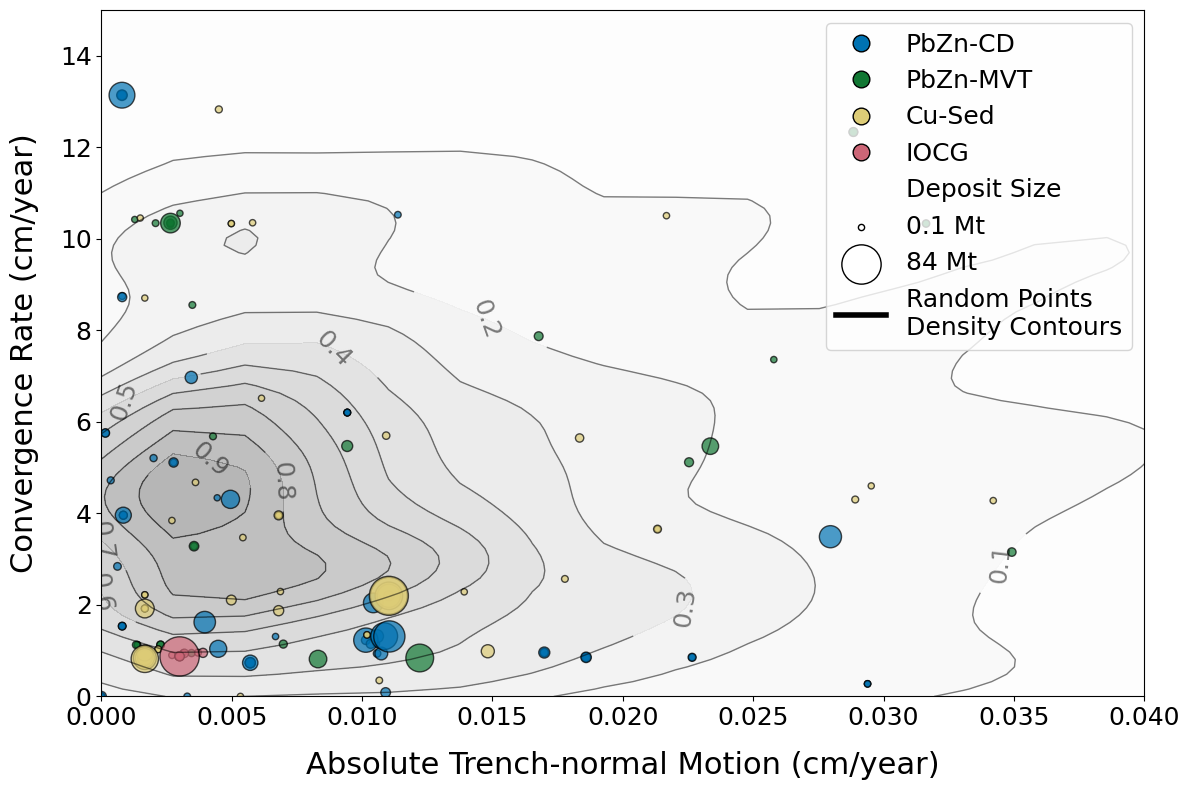

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Load your CSV file into a DataFrame
file_path = 'deposits_VS_random.csv'  # Update with your file path
df = pd.read_csv(file_path)

# Define columns
x_deposit = 'D_tr_adv_m'
y_deposit = 'D_sb_ve'
x_random = 'R_tr_adv_m'
y_random = 'R_sb_ve'
weights_column = 'TM2'

# Select relevant columns
deposit_data = df[[x_deposit, y_deposit, weights_column, 'Type']]
random_data = df[[x_random, y_random]]

# Filter: Keep only rows with valid (non-negative) y-values
deposit_data = deposit_data[deposit_data[y_deposit] >= 0]
random_data = random_data[random_data[y_random] >= 0]

# Apply absolute value to trench-normal motion
x_deposit_values = deposit_data[x_deposit].abs()
x_random_values = random_data[x_random].abs()

# Replace the x-columns in original DataFrames with abs values
deposit_data[x_deposit] = x_deposit_values
random_data[x_random] = x_random_values

# Extract y-values and other data
y_deposit_values = deposit_data[y_deposit]
y_random_values = random_data[y_random]
deposit_weights = deposit_data[weights_column]
deposit_types = deposit_data['Type']

# Define colors for deposit types
type_colors = {
    'PbZn-CD': '#0072B2',   # Blue
    'PbZn-MVT': '#117733',  # Green
    'Cu-Sed': '#DDCC77',    # Yellow
    'IOCG': '#CC6677',      # Pink
    'Unknown': 'gray'       # For unknown types
}

# Map TM2 to marker sizes (scaled)
min_size, max_size = 20, 800
scaled_sizes = (deposit_weights - deposit_weights.min()) / (deposit_weights.max() - deposit_weights.min())
scaled_sizes = scaled_sizes * (max_size - min_size) + min_size

# Set plot boundaries
xmin, xmax = 0, max(x_random_values.max(), x_deposit_values.max()) * 1.1
ymin, ymax = 0, 16
xx, yy = np.meshgrid(np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100))

# Compute KDE density for random points
values = np.vstack([x_random_values, y_random_values])
kde = gaussian_kde(values)
density = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
density_normalized = density / density.max()

# Create the figure
plt.figure(figsize=(12, 8))

# Plot filled KDE contours
contour = plt.contourf(xx, yy, density_normalized, levels=10, cmap='Greys', alpha=0.3)
cset = plt.contour(xx, yy, density_normalized, levels=10, colors='black', linewidths=1, alpha=0.5)
plt.clabel(cset, inline=True, fontsize=18, fmt="%.1f")

# Plot deposit points with scaled sizes and colored by type
for deposit_type in deposit_types.unique():
    if pd.isna(deposit_type) or deposit_type == 'Unknown':
        continue
    type_data = deposit_data[deposit_data['Type'] == deposit_type]
    plt.scatter(type_data[x_deposit], type_data[y_deposit],
                s=scaled_sizes[type_data.index],
                color=type_colors.get(deposit_type, 'gray'),
                edgecolor='black', alpha=0.7, label=deposit_type, marker='o')

# Build custom legend
legend_elements = []
for deposit_type, color in type_colors.items():
    if deposit_type != 'Unknown':
        legend_elements.append(plt.Line2D([0], [0], marker='o', color=color, label=deposit_type,
                                          markersize=12, markeredgecolor='black', linestyle='None'))

legend_elements.append(plt.Line2D([0], [0], label='Deposit Size', color='none', markersize=20))
legend_elements.append(plt.scatter([], [], s=min_size, color='white', alpha=1, edgecolor='black', label='0.1 Mt', marker='o'))
legend_elements.append(plt.scatter([], [], s=max_size, color='white', alpha=1, edgecolor='black', label='84 Mt', marker='o'))

legend_elements.append(plt.Line2D([0], [0], color='black', linewidth=4, label='Random Points\nDensity Contours'))

# Apply axis settings
plt.xlim(0, 0.04)
plt.ylim(ymin, 15)
plt.xlabel('Absolute Trench-normal Motion (cm/year)', fontsize=22, labelpad=15)
plt.ylabel('Convergence Rate (cm/year)', fontsize=22, labelpad=15)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Show legend
plt.legend(handles=legend_elements, loc='upper right', frameon=True,
           labelspacing=0.5, fontsize=18, title_fontsize=20, title="")

plt.tight_layout()
plt.show()
